# This is a python algorithm creation for the CNN_LSTM model

In [38]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


In [39]:
#pd.options.display.max_rows = 700
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

#print(df.to_string())
#df.plot.area(alpha=0.4) #Displays area chart

#df.head()   #Outputs the first row headers

#df.plot.bar(stacked=True) 
#df['6'].plot.hist(bins=50) 
#df.plot.scatter(x='6', y='148') 
#df.plot.density() 

X = df.drop(columns=[]).values
y = df['Label'].values

input_shape = df.shape
print("Input shape:", input_shape)


Input shape: (2323670, 13)


In [40]:

# Reshape X for compatibility with Conv1D layer
X = X.reshape(X.shape[0], X.shape[1], 1)
# Make sure X_train, X_val, y_train, y_val are in the right format (numpy arrays)

# Split data into train and validation sets
#X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Split the data into training, validation, and testing sets
#X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
#X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)


# Define the number of folds for cross-validation
n_folds = 5

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the results
test_losses = []
test_accuracies = []
y_true_list = []
y_pred_list = []

# Perform k-fold cross-validation
for train_index, test_index in kf.split(X):
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

In [41]:
# Define the model
model = Sequential()

# Convolutional layers
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# LSTM layer
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))

# Flatten before dense layer
model.add(Flatten())

# Dense layers
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.5))  # Regularization to prevent overfitting
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy','recall'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=2, batch_size=32, validation_data=(X_val, y_val))


C:\Users\NK\anaconda3_11\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 11, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 320)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          20,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,569 (178.00 KB)

 Trainable params: 45,569 (178.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 285s 5ms/step - accuracy: 0.9970 - loss: 0.0083 - recall: 0.9976 - val_accuracy: 1.0000 - val_loss: 5.2202e-10 - val_recall: 1.0000
Epoch 2/2
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 262s 5ms/step - accuracy: 1.0000 - loss: 1.3839e-04 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.6547e-08 - val_recall: 1.0000


In [46]:
# Evaluate the model on the test set for the current fold
test_results = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
test_loss = test_results[0]
test_accuracy = test_results[1]
test_losses.append(test_loss)
test_accuracies.append(test_accuracy)
    
    # Make predictions on the test set for the current fold
y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
y_pred_binary = (y_pred > 0.5).astype(int)
y_true_list.append(y_test)
y_pred_list.append(y_pred_binary)

 4460/14523 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step

KeyboardInterrupt: 

In [43]:
 # Evaluate the model on the test set for the current fold
test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
test_losses.append(test_loss)
test_accuracies.append(test_accuracy)
    
    # Make predictions on the test set for the current fold
y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
y_pred_binary = (y_pred > 0.5).astype(int)
y_true_list.append(y_test)
y_pred_list.append(y_pred_binary)

# Calculate the average test loss and accuracy
mean_test_loss = np.mean(test_losses)
mean_test_accuracy = np.mean(test_accuracies)

print(f"Mean Test Loss: {mean_test_loss:.4f}")
print(f"Mean Test Accuracy: {mean_test_accuracy:.4f}")

# Concatenate the true labels and predicted labels from all folds
y_true = np.concatenate(y_true_list)
y_pred = np.concatenate(y_pred_list)

# Print the classification report
print("Classification Report:")
print(classification_report(y_true, y_pred))

# Calculate the confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(confusion_mat)

ValueError: too many values to unpack (expected 2)

In [ ]:
from sklearn.metrics import confusion_matrix

# Assuming model is already trained and X_test, y_test are your test data
# Use the trained model to make predictions on the test data
y_pred = model.predict(X)

# Convert predicted probabilities to binary predictions
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Extract true negatives (TN), false positives (FP), false negatives (FN), true positives (TP) from confusion matrix
TN, FP, FN, TP = cm.ravel()

# Calculate false positive rate (FPR)
FPR = FP / (FP + TN)

print("False Positives:", FP)
print("False Positive Rate:", FPR)


74969/74969 ━━━━━━━━━━━━━━━━━━━━ 134s 2ms/step


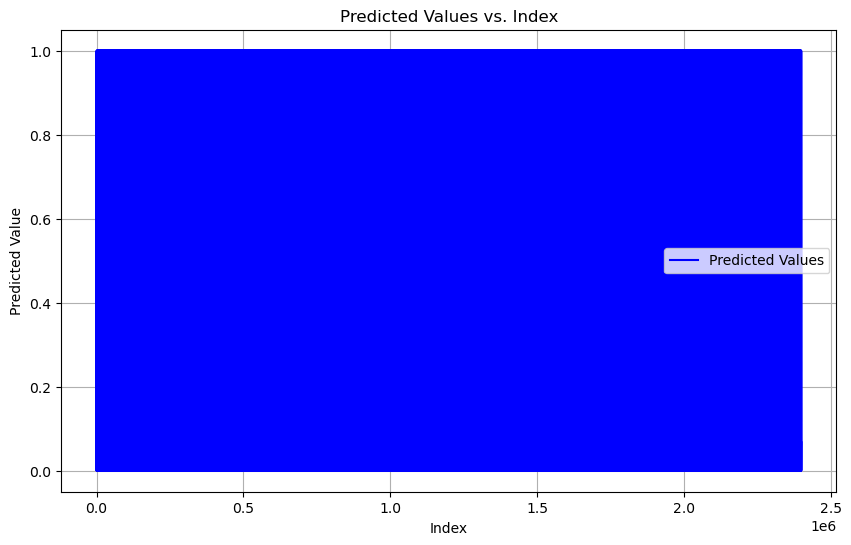

In [8]:

import matplotlib.pyplot as plt

# Make predictions on the validation data
predictions = model.predict(X_val)

# Plot the predicted values
plt.figure(figsize=(10, 6))
plt.plot(predictions, label='Predicted Values', color='blue')
plt.xlabel('Index')
plt.ylabel('Predicted Value')
plt.title('Predicted Values vs. Index')
plt.legend()
plt.grid(True)
plt.show()

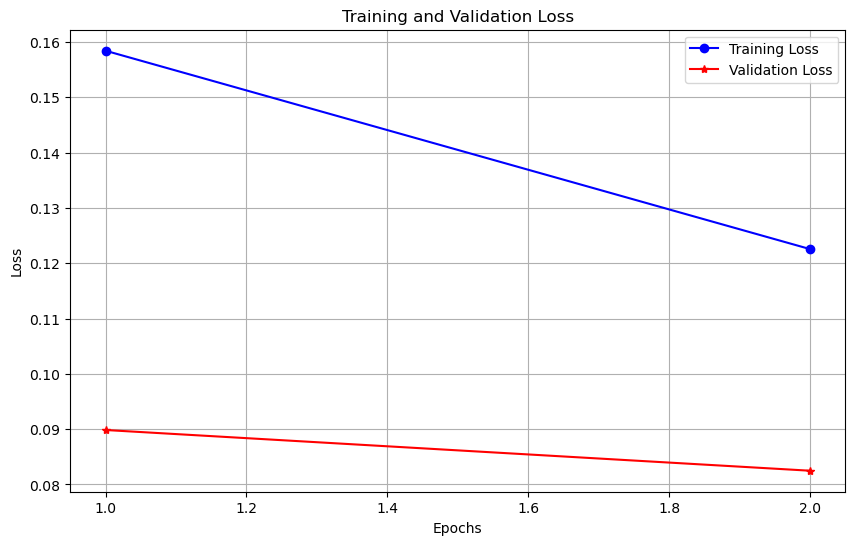

In [9]:
import matplotlib.pyplot as plt

# Extracting training history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)

# Plotting training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, training_loss, 'bo-', label='Training Loss')
plt.plot(epochs, validation_loss, 'r*-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


74969/74969 ━━━━━━━━━━━━━━━━━━━━ 136s 2ms/step


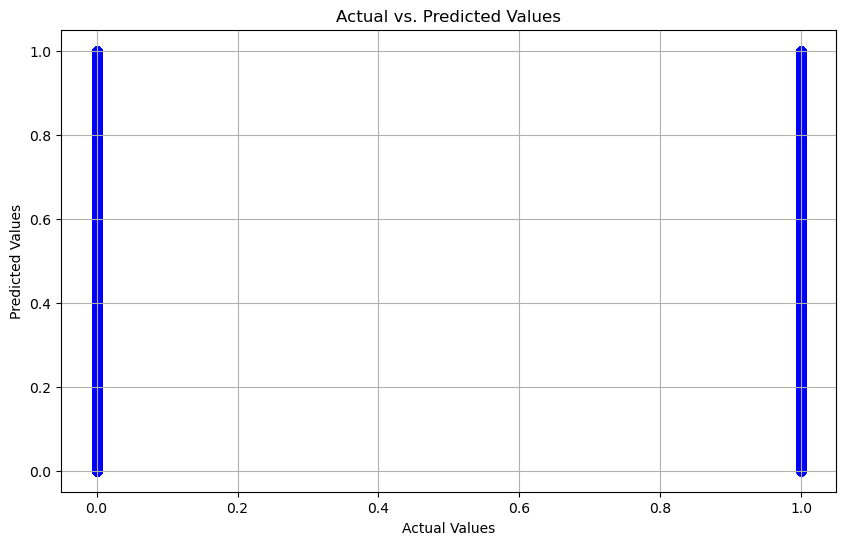

In [10]:
import matplotlib.pyplot as plt

# Make predictions on the validation data
predictions = model.predict(X_val)

# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, predictions, color='blue')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()


In [33]:
# Evaluate the model on the test data
test_loss, test_accuracy, *_ = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions on the test data
y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
y_pred_binary = (y_pred > 0.5).astype(int)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_binary))

confusion_mat = confusion_matrix(y_test, y_pred_binary)
print("Confusion Matrix:")

10893/10893 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 1.0000 - loss: 2.8315e-12 - recall: 1.0000
Test Loss: 0.0000
Test Accuracy: 1.0000
 5858/10893 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step

KeyboardInterrupt: 

In [1]:
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv('NF-UQ-NIDS.csv')

# Check for missing values in the DataFrame
missing_values = df.isnull().sum()

# Print the count of missing values for each column
print("Missing values in each column:")
print(missing_values)

# Optionally, you can check if there are any missing values in the entire DataFrame
if df.isnull().values.any():
    print("There are missing values in the DataFrame.")
else:
    print("No missing values found in the DataFrame.")

Missing values in each column:
IPV4_SRC_ADDR                 0
L4_SRC_PORT                   0
IPV4_DST_ADDR                 0
L4_DST_PORT                   0
PROTOCOL                      0
L7_PROTO                      0
IN_BYTES                      0
OUT_BYTES                     0
IN_PKTS                       0
OUT_PKTS                      0
TCP_FLAGS                     0
FLOW_DURATION_MILLISECONDS    0
Label                         0
Attack                        0
Dataset                       0
dtype: int64
No missing values found in the DataFrame.


Index(['IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT',
       'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
       'TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'Label', 'Attack',
       'Dataset'],
      dtype='object')


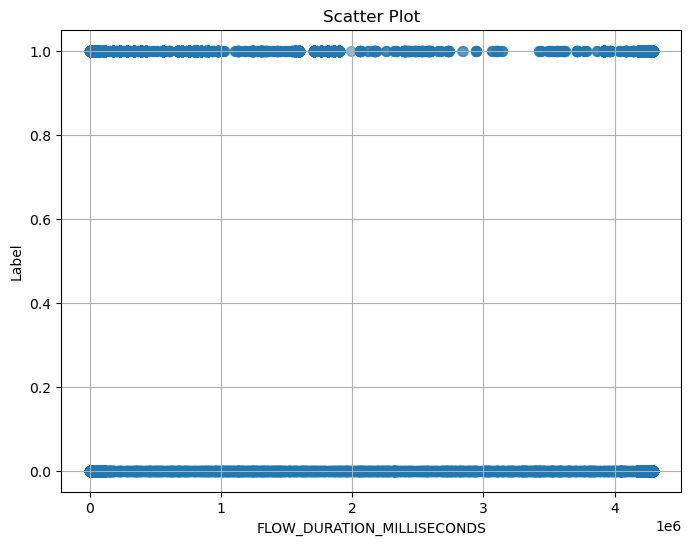

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the dataset into a pandas DataFrame
# Replace 'your_dataset.csv' with the path to your dataset
df = pd.read_csv('NF-UQ-NIDS.csv')

# Print the columns of the DataFrame to identify the correct column names
print(df.columns)

# Assuming your dataset has two columns you want to plot, replace 'x' and 'y' with the actual column names
plt.figure(figsize=(8, 6))  # Set the figure size (optional)
plt.scatter(df['FLOW_DURATION_MILLISECONDS'], df['Label'], s=50, alpha=0.5)  # Plot the scatter plot
plt.title('Scatter Plot')  # Set the title of the plot
plt.xlabel('FLOW_DURATION_MILLISECONDS')  # Set the label for the X-axis
plt.ylabel('Label')  # Set the label for the Y-axis
plt.grid(True)  # Add grid lines (optional)
plt.show()  # Display the plot







In [21]:
import pandas as pd

# Sample DataFrame with IPv4 addresses

df = pd.read_csv('New1_NF-UQ-NIDS.csv')

ip_address_column = df['IPV4_DST_ADDR']
print(ip_address_column)

# Function to convert IPv4 address to integer
def ip_to_int(ip):
    octets = ip.split('.')
    int_ip = (int(octets[0]) << 24) + (int(octets[1]) << 16) + (int(octets[2]) << 8) + int(octets[3])
    return int_ip

# Convert the 'IP_Address' column to integer
df['Integer_IPV4_DST_ADDR'] = df['IPV4_DST_ADDR'].apply(ip_to_int)

# Display the DataFrame with the new 'Integer_IP' column
print(df)
# Write the modified DataFrame back to a CSV file
df.to_csv('New2_NF-UQ-NIDS.csv', index=False)

0            192.168.1.152
1             172.31.69.25
2             172.31.69.25
3            149.171.126.1
4          213.202.230.206
                ...       
5000665     107.178.240.89
5000666       172.31.65.30
5000667      149.171.126.8
5000668        192.168.1.1
5000669       172.31.66.61
Name: IPV4_DST_ADDR, Length: 5000670, dtype: object
          IPV4_SRC_ADDR  L4_SRC_PORT    IPV4_DST_ADDR  L4_DST_PORT  PROTOCOL  \
0          192.168.1.30        52742    192.168.1.152           80         6   
1          18.218.11.51        55409     172.31.69.25           80         6   
2          18.221.219.4        52916     172.31.69.25           21         6   
3            59.166.0.9        19161    149.171.126.1         5190         6   
4          172.31.64.97         3389  213.202.230.206        36692         6   
...                 ...          ...              ...          ...       ...   
5000665    172.31.68.21        51004   107.178.240.89          443         6   
5000666   1

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

# Read the CSV dataset into a DataFrame
data = pd.read_csv('NF-UQ-NIDS-v2.csv')

# Assuming 'target_column' is the column representing the classes
target_column = 'Attack'

# Compute the number of rows in the dataset
total_rows = len(data)

# Split the dataset into two halves
first_half_size = total_rows // 2
second_half_size = total_rows - first_half_size

# Read the first half of the dataset
first_half_data = pd.read_csv('NF-UQ-NIDS-v2.csv', nrows=first_half_size)

# Read the second half of the dataset, skipping the first half
second_half_data = pd.read_csv('NF-UQ-NIDS-v2.csv', skiprows=range(1, first_half_size+1))

# Create an instance of StratifiedShuffleSplit
stratified_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.973, random_state=42)

# Generate the indices for stratified sampling for the first half
for train_index, test_index in stratified_splitter.split(first_half_data, first_half_data[target_column]):
    # Get the train and test data based on the generated indices for the first half
    train_data_first_half = first_half_data.iloc[train_index]
    test_data_first_half = first_half_data.iloc[test_index]

# Generate the indices for stratified sampling for the second half
for train_index, test_index in stratified_splitter.split(second_half_data, second_half_data[target_column]):
    # Get the train and test data based on the generated indices for the second half
    train_data_second_half = second_half_data.iloc[train_index]
    test_data_second_half = second_half_data.iloc[test_index]

# Concatenate the train data from both halves
train_data = pd.concat([train_data_first_half, train_data_second_half])

# Concatenate the test data from both halves
test_data = pd.concat([test_data_first_half, test_data_second_half])

# Save the sampled train and test data to CSV files
train_data.to_csv('NF-UQ-NIDS-v2_stratified_train_data.csv', index=False)
test_data.to_csv('sampled_test_data.csv', index=False)

# Now you have train and test datasets with stratified sampling saved as CSV files for both halves


In [6]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load dataset from CSV file
data = pd.read_csv('output_normalized_min_max.csv')  # Replace 'your_dataset.csv' with the path to your CSV file
X = data.drop(columns=['Label'])  # Assuming 'target_column' is the name of the target variable
y = data['Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Lasso model
lasso = Lasso(alpha=0.01)  # You can adjust the regularization parameter alpha

# Fit Lasso model to the training data
lasso.fit(X_train_scaled, y_train)

# Get the coefficients of the Lasso model
lasso_coefs = lasso.coef_

# Print the non-zero coefficients and their corresponding feature names
selected_features = X.columns[np.where(lasso_coefs != 0)]
print("Selected features:", selected_features)

# Evaluate the model performance on the test set
test_score = lasso.score(X_test_scaled, y_test)
print("Test set R^2 score:", test_score)


Selected features: Index(['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
       'FLOW_DURATION_MILLISECONDS', 'Integer_IPV4_SRC_ADDR',
       'Integer_IPV4_DST_ADDR'],
      dtype='object')
Test set R^2 score: 0.35576007747706584


In [7]:
pip install boruta



   ---------------------------------------- 0.0/56.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/56.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/56.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   ------- -------------------------------- 10.2/56.6 kB ? eta -:--:--
   --------------------- ------------------ 30.7/56.6 kB 54.6 kB/s eta 0:00:01
   --------------------- ------------------ 30.7/56.6 kB 54.6 kB/s eta 0

In [7]:
import pandas as pd
from minisom import MiniSom
import numpy as np

# Step 2: Load data from CSV
data = pd.read_csv('output_normalized_min_max.csv')  # Replace 'your_dataset.csv' with the path to your CSV file
X = data.drop(columns=['Label'])  # Assuming 'target_column' is the name of the target variable

# Step 3: Normalize data
X_normalized = (X - X.min()) / (X.max() - X.min())

# Step 4: Train the SOM
som = MiniSom(x=10, y=10, input_len=X_normalized.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_normalized.values)
som.train_batch(X_normalized.values, 1000)

# Step 5: Calculate feature importance
neuron_distances = som.distance_map()
feature_importance = np.mean(neuron_distances, axis=(0, 1))

# Print feature importance
print("Feature importance:", feature_importance)

# Step 6: Rank features
ranked_features = np.argsort(feature_importance)[::-1]

# Print ranked features
print("Ranked features:", ranked_features)

# Step 7: Select important features (e.g., top 5)
num_selected_features = 5
selected_features = ranked_features[:num_selected_features]

# Get the names of the selected features
selected_feature_names = [X.columns[i] for i in selected_features]

# Print selected features
print("Selected features:", selected_feature_names)


Feature importance: 0.5166141002376914
Ranked features: [0]
Selected features: ['L4_SRC_PORT']


In [11]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
import pandas as pd

# Step 2: Load data from CSV
data = pd.read_csv('output_normalized_min_max.csv')  # Replace 'your_dataset.csv' with the path to your CSV file
X = data.drop(columns=['Label'])  # Assuming 'target_column' is the name of the target variable
y = data['Label']  # Assuming 'target_column' is the name of the target variable

# Step 3: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Feature selection using SelectKBest
k = 12  # Number of features to select
selector = SelectKBest(score_func=f_classif, k=k)  # Using F-value for scoring function
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Step 6: Get selected features
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]

# Print selected feature names
print("Selected features:", selected_feature_names)


Selected features: Index(['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES',
       'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'TCP_FLAGS',
       'FLOW_DURATION_MILLISECONDS', 'Integer_IPV4_SRC_ADDR',
       'Integer_IPV4_DST_ADDR'],
      dtype='object')


In [12]:

# Step 5: Get selected features and their scores
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]
selected_feature_scores = selector.scores_[selected_feature_indices]

# Print selected feature names and scores
print("Selected features and their scores:")
for name, score in zip(selected_feature_names, selected_feature_scores):
    print(f"Feature: {name}, Score: {score}")

Selected features and their scores:
Feature: L4_SRC_PORT, Score: 132411.922769287
Feature: L4_DST_PORT, Score: 201590.90387479131
Feature: PROTOCOL, Score: 82749.47476353566
Feature: L7_PROTO, Score: 32912.37017722578
Feature: IN_BYTES, Score: 588.2647545258475
Feature: OUT_BYTES, Score: 530.8932841189248
Feature: IN_PKTS, Score: 1337.9521014190354
Feature: OUT_PKTS, Score: 184.99606997756305
Feature: TCP_FLAGS, Score: 14261.445564007072
Feature: FLOW_DURATION_MILLISECONDS, Score: 514673.3889839227
Feature: Integer_IPV4_SRC_ADDR, Score: 25135.364454390405
Feature: Integer_IPV4_DST_ADDR, Score: 267785.3724755456


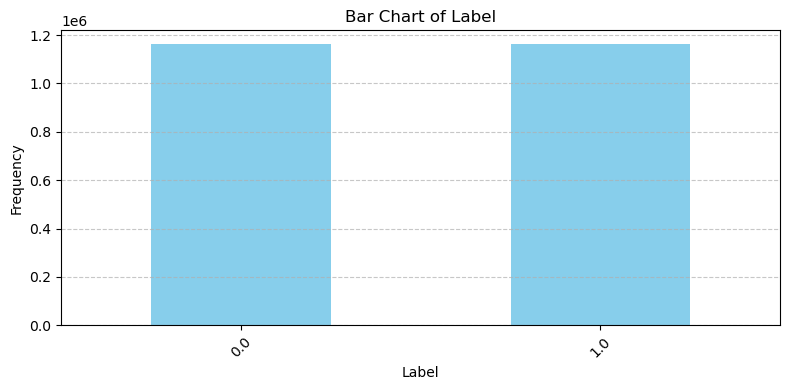

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load Dataset
data = pd.read_csv('min_max_undersampled_dataset.csv')  # Replace 'your_dataset.csv' with the path to your CSV file

# Step 2: Extract Data
column_name = 'Label'  # Replace 'column_of_interest' with the name of the column you want to plot
column_values = data[column_name]

# Step 3: Plot Bar Chart
plt.figure(figsize=(8, 4))  # Set the figure size (width, height)
column_values.value_counts().plot(kind='bar', color='skyblue')  # Plot the bar chart
plt.title('Bar Chart of ' + column_name)  # Set the title of the plot
plt.xlabel(column_name)  # Set the label for the x-axis
plt.ylabel('Frequency')  # Set the label for the y-axis
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for the y-axis
plt.tight_layout()  # Adjust layout to prevent overlap of labels
plt.show()  # Show the plot


In [3]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('output_normalized_min_max.csv')

# Assuming the target variable is named 'target', and it's binary (0 and 1)
# Separate majority and minority classes
majority_class = df[df['Label'] == 0]
minority_class = df[df['Label'] == 1]

# Determine the size of the majority class after undersampling
undersampled_size = len(minority_class)

# Undersample the majority class randomly
undersampled_majority = majority_class.sample(n=undersampled_size, random_state=42)

# Combine the undersampled majority class with the minority class
undersampled_df = pd.concat([undersampled_majority, minority_class])

# Optionally, shuffle the rows
undersampled_df = undersampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the undersampled dataset to a new CSV file
undersampled_df.to_csv('min_max_undersampled_dataset.csv', index=False)


In [13]:
import pandas as pd

# Load the dataset into a pandas DataFrame
df = pd.read_csv('min_max_undersampled_dataset.csv')

# Shuffle the rows of the DataFrame
shuffled_df = df.sample(frac=1, random_state=42)

# Optionally, reset the index after shuffling
shuffled_df = shuffled_df.reset_index(drop=True)

# Save the shuffled dataset to a new CSV file
shuffled_df.to_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv', index=False)


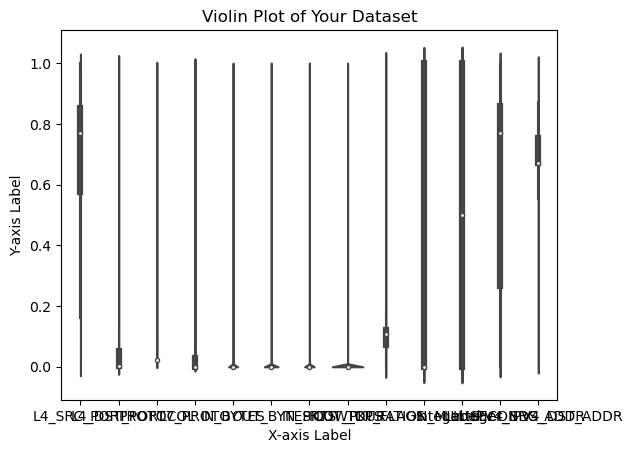

In [21]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset into a pandas DataFrame (replace 'your_dataset.csv' with the actual filename)
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Create a violin plot using Seaborn
sns.violinplot(data=df)

# Optionally, set labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Violin Plot of Your Dataset')

# Show the plot
plt.show()


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load the normalized dataset into a pandas DataFrame
normalized_df = pd.read_csv('output_normalized_min_max.csv')

# Load the non-normalized dataset into another pandas DataFrame
non_normalized_df = pd.read_csv('Strat__NF-UQ-NIDS.csv')

# Plot histograms of numerical features from both datasets
plt.figure(figsize=(12, 6))

# Plot histograms of numerical features from the normalized dataset
plt.subplot(1, 2, 1)
for column in normalized_df.columns:
    sns.histplot(normalized_df[column], kde=True, label=column)
plt.title('Normalized Dataset')
plt.legend()

# Plot histograms of numerical features from the non-normalized dataset
plt.subplot(1, 2, 2)
for column in non_normalized_df.columns:
    sns.histplot(non_normalized_df[column], kde=True, label=column)
plt.title('Non-Normalized Dataset')
plt.legend()

plt.tight_layout()
plt.show()


C:\Users\NK\AppData\Local\Temp\ipykernel_11456\4045283529.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, shade=True, color='blue')  # Adjust color as needed


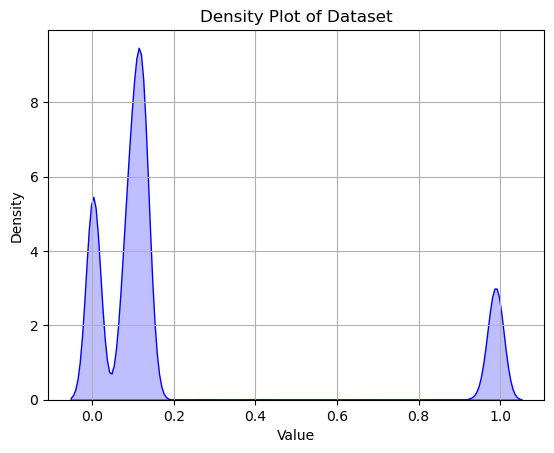

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')  # Replace 'your_dataset.csv' with the path to your CSV file

# Assuming your dataset has a column named 'value' that you want to plot
data = df['TCP_FLAGS']

# Plotting the density plot
sns.kdeplot(data, shade=True, color='blue')  # Adjust color as needed
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Density Plot of Dataset')
plt.grid(True)
plt.show()


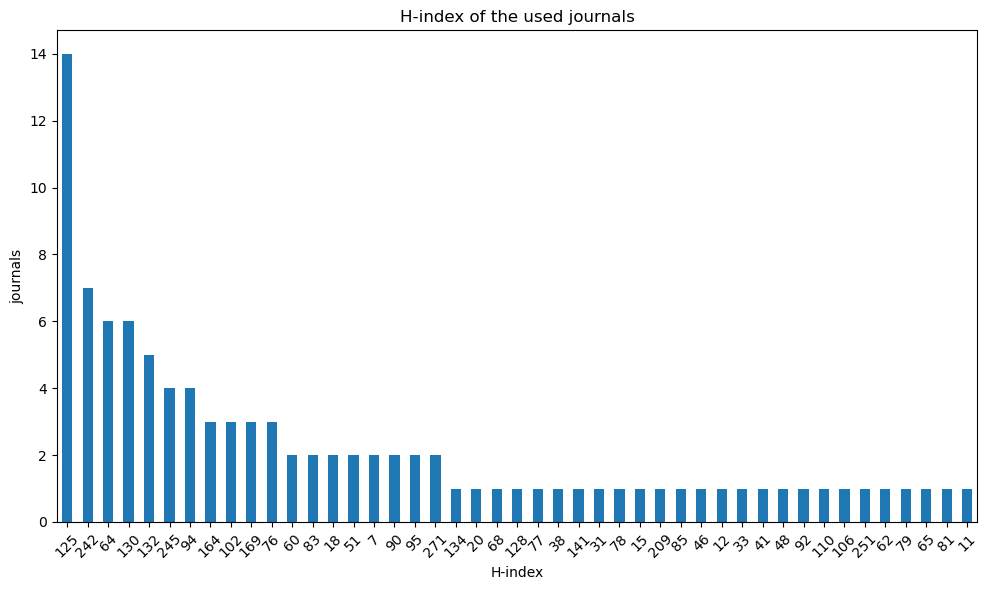

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset from a CSV file
data = pd.read_csv('References.csv')

# Assuming 'column_name' is the column containing the categories in string format
column_name = 'H-index'

# Compute the frequency of each category
category_counts = data[column_name].value_counts()

# Plot the distribution
plt.figure(figsize=(10, 6))  # Adjust the figure size if needed
category_counts.plot(kind='bar')
plt.title('H-index of the used journals')
plt.xlabel('H-index')
plt.ylabel('journals')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


C:\Users\NK\AppData\Local\Temp\ipykernel_11588\3090006209.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()  # Adjust layout to prevent clipping of labels


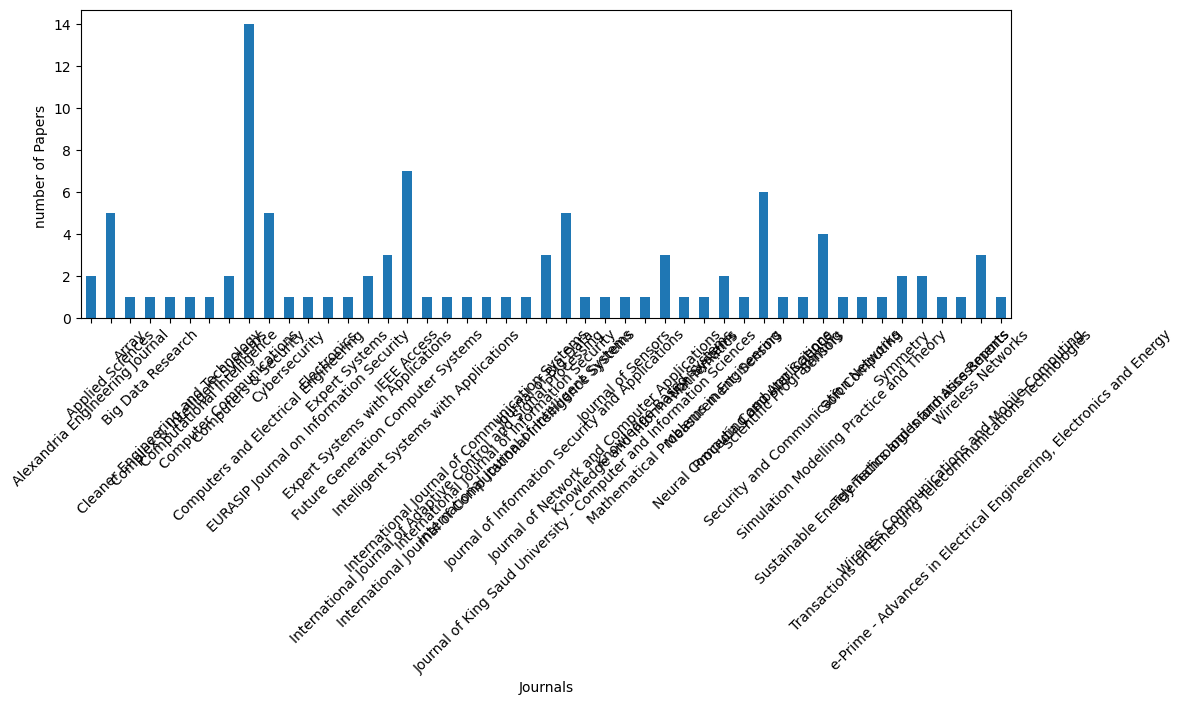

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset from a CSV file
data = pd.read_csv('References.csv')

# Display the first few rows of the dataset to verify the contents
#print(data.head())

# Assuming 'H-index' is the column containing the categories in string format
column_name = 'Journal'

# Compute the frequency of each category
category_counts = data[column_name].value_counts()

# Sort the category counts by index (H-index) in ascending order
category_counts = category_counts.sort_index(ascending=True)

# Plot the distribution as a horizontal bar plot with H-index on the x-axis
plt.figure(figsize=(12, 4))  # Adjust the figure size if needed
category_counts.plot(kind='bar')

plt.xlabel('Journals')
plt.ylabel('number of Papers ')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()



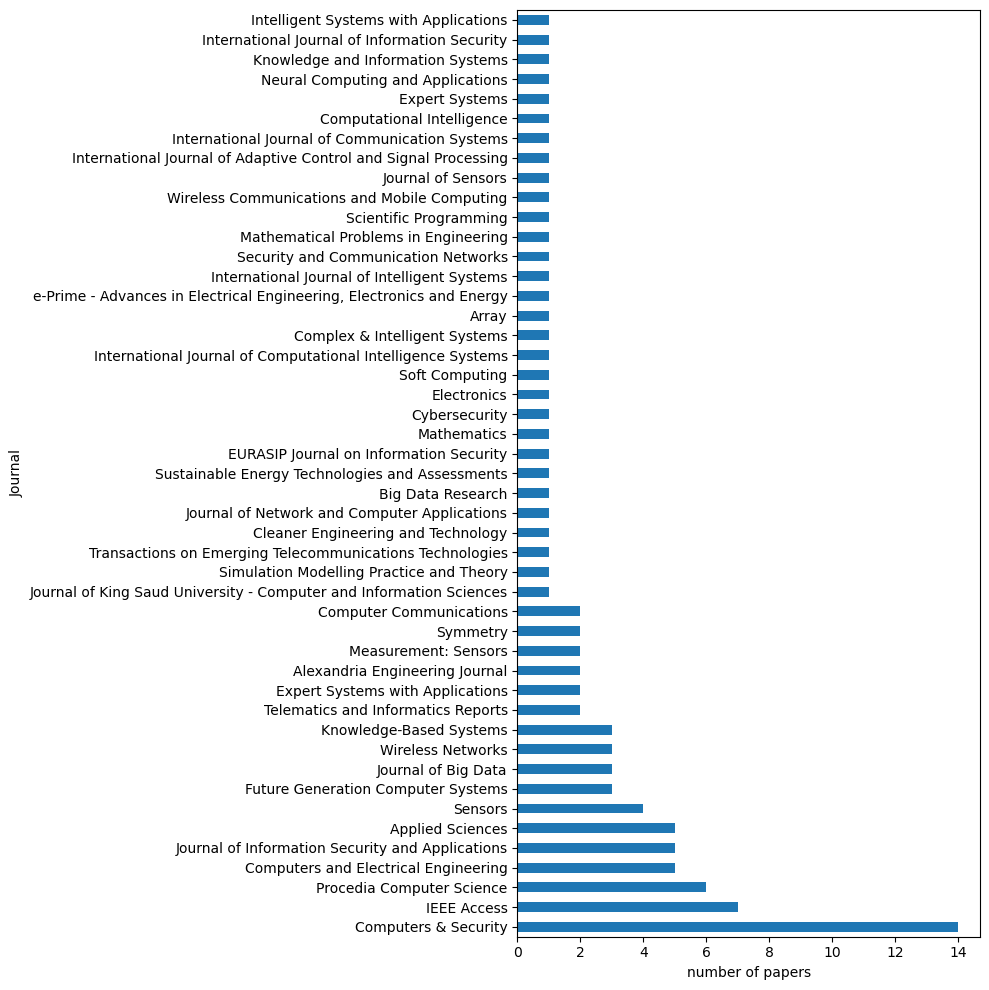

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset from a CSV file
data = pd.read_csv('References.csv')



# Assuming 'H-index' is the column containing the categories in string format
column_name = 'Journal'

# Compute the frequency of each category
category_counts = data[column_name].value_counts()

# Plot the distribution as a horizontal bar plot
plt.figure(figsize=(10,10 ))  # Adjust the figure size if needed
category_counts.plot(kind='barh')

plt.xlabel('number of papers')
plt.ylabel('Journal')
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


In [50]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report
import time

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values

# Get the input shape
input_shape = X.shape
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 5

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the CNN-LSTM model
    model = Sequential()
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
              epochs=10, batch_size=32, verbose=1)
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Input shape: (2323670, 12)
Fold 1/5


C:\Users\NK\anaconda3_11\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 328s 6ms/step - accuracy: 0.9458 - loss: 0.1500
Epoch 2/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 339s 6ms/step - accuracy: 0.9808 - loss: 0.0690
Epoch 3/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 350s 6ms/step - accuracy: 0.9842 - loss: 0.0600
Epoch 4/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 361s 6ms/step - accuracy: 0.9849 - loss: 0.0574
Epoch 5/10
26577/58092 ━━━━━━━━━━━━━━━━━━━━ 3:01 6ms/step - accuracy: 0.9853 - loss: 0.0559

KeyboardInterrupt: 

In [51]:
model.summary

<bound method Model.summary of <Sequential name=sequential_6, built=True>>

In [52]:
# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'train_loss_histories' is not defined

<Figure size 1000x600 with 0 Axes>

In [59]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import time
import matplotlib.pyplot as plt
from prettytable import PrettyTable

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values

# Get the input shape
input_shape = X.shape
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 2

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the CNN-LSTM model
    model = Sequential()
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                       epochs=2, batch_size=32, validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Print the model architecture
print("Model Architecture:")
table = PrettyTable()
table.field_names = ["Layer (type)", "Output Shape", "Param #"]
for layer in model.layers:
    table.add_row([layer.__class__.__name__, str(layer.output_shape), layer.count_params()])
print(table)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Input shape: (2323670, 12)
Fold 1/2


C:\Users\NK\anaconda3_11\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model Summary:


Model: "sequential_7"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)                    │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

KeyboardInterrupt: 

Input shape: (2323670, 12)
Fold 1/2
Model Summary:


Model: "sequential_9"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)                    │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

Model: "sequential_10"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_17 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

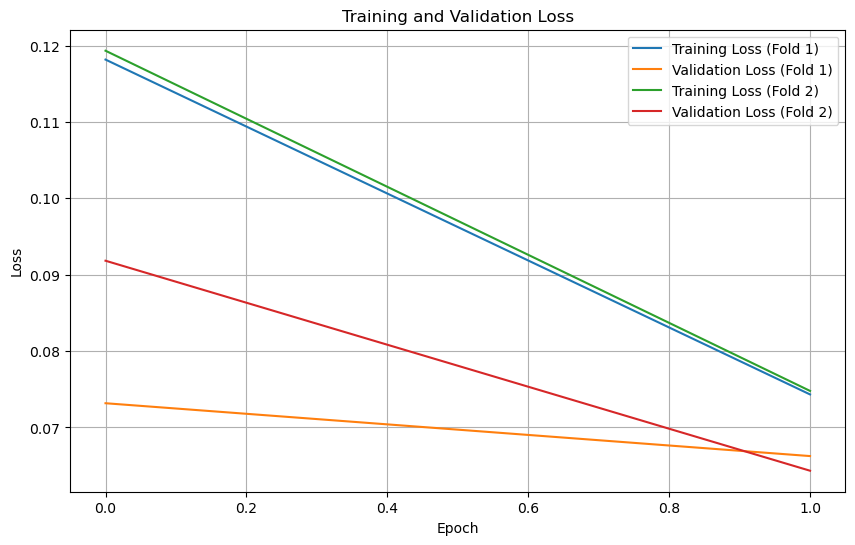

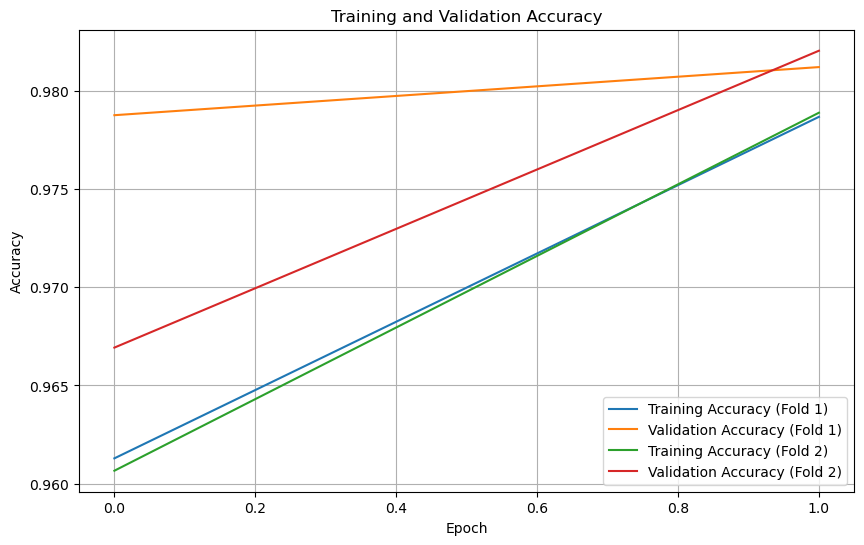

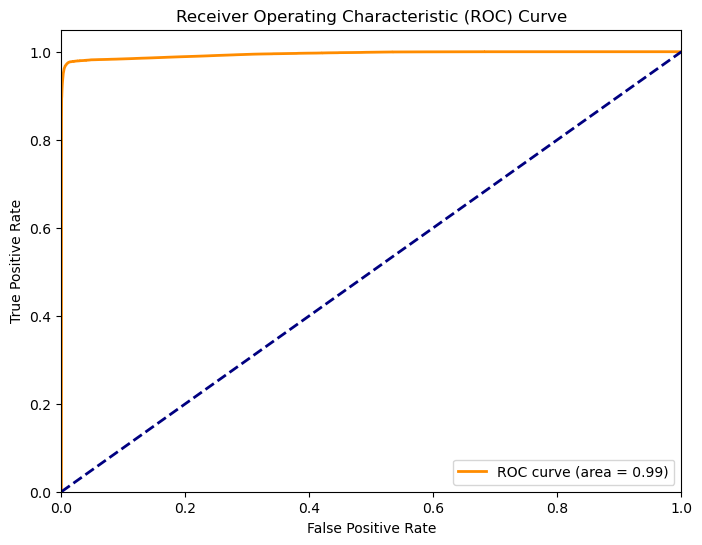

In [62]:
plt.savefig('loss_plot.png')

<Figure size 640x480 with 0 Axes>

Input shape: (2323670, 12)
Fold 1/5
Model Summary:


Model: "sequential_38"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_16 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_24 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_52 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

Model: "sequential_39"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_17 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_26 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_54 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

Model: "sequential_40"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_18 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_28 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_56 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

Model: "sequential_41"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_19 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_19 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_30 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

Model: "sequential_42"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_20 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_32 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_60 (Dropout)                 │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

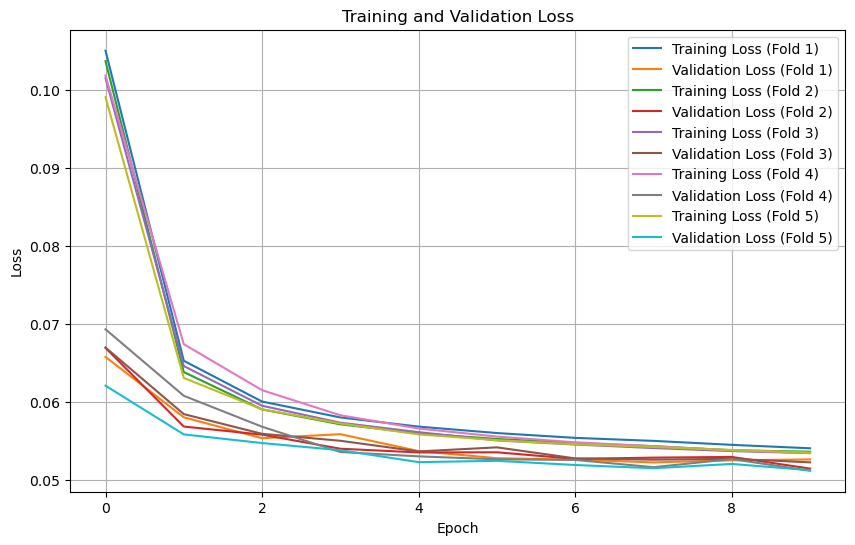

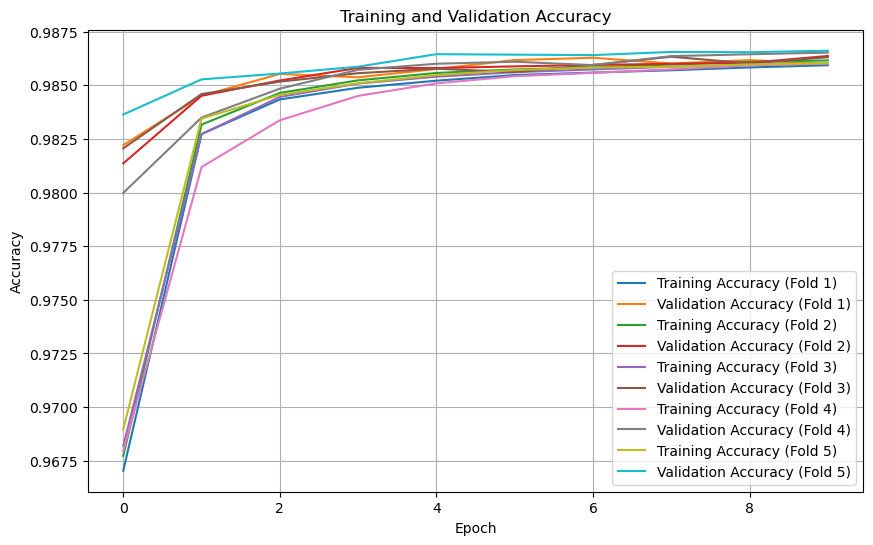

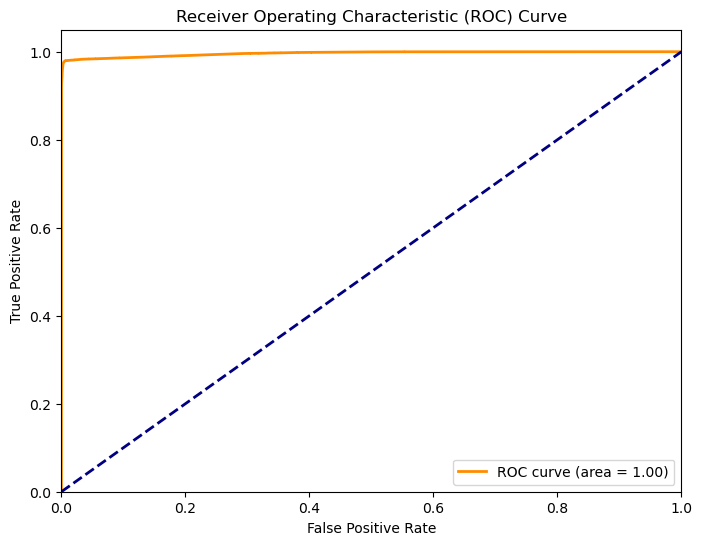

In [35]:
#CNN-LSTM
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import time
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras.utils import plot_model 

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values

# Get the input shape
input_shape = X.shape
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 5

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the CNN-LSTM model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], 1)))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                       epochs=10, batch_size=32, validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0,0], cm[0,1]])
    table.add_row(["Actual Positive", cm[1,0], cm[1,1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')

In [4]:
from tensorflow.keras.utils import plot_model 
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
print('Model architecture saved as model_architecture.png')

Model architecture saved as model_architecture.png


In [ ]:
# CNN Bi-LSTM MODEL

import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import time
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
from prettytable import PrettyTable

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values

# Get the input shape
input_shape = X.shape
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 2

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the CNN-Bi-LSTM model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], 1)))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Bidirectional(LSTM(64, return_sequences=True, activation='relu')))
    model.add(Dropout(0.2))
    model.add(Bidirectional(LSTM(32, activation='relu')))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Generate the model architecture image
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    print('Model architecture saved as model_architecture.png')
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                       epochs=50, batch_size=32, validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0,0], cm[0,1]])
    table.add_row(["Actual Positive", cm[1,0], cm[1,1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')

Input shape: (2323670, 12)
Fold 1/2
Model Summary:


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 5, 128)              │          49,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 5, 128)              │          49,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

Input shape: (2323670, 12)
Fold 1/2

Model Summary:


Model: "sequential_12"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_12 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_16 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_5 (Attention)              │ (None, 5, 64)               │              69 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

Model: "sequential_13"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_13 (Conv1D)                   │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_13 (MaxPooling1D)      │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_18 (LSTM)                       │ (None, 5, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_6 (Attention)              │ (None, 5, 64)               │              69 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

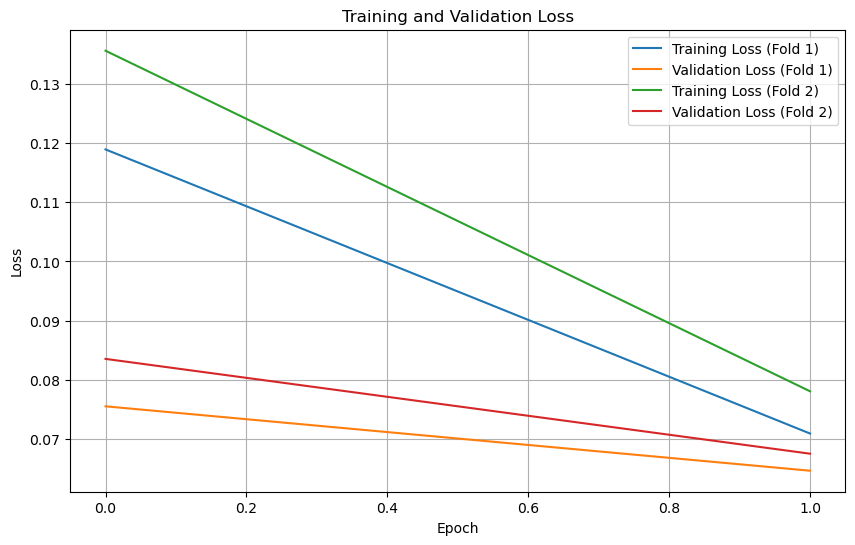

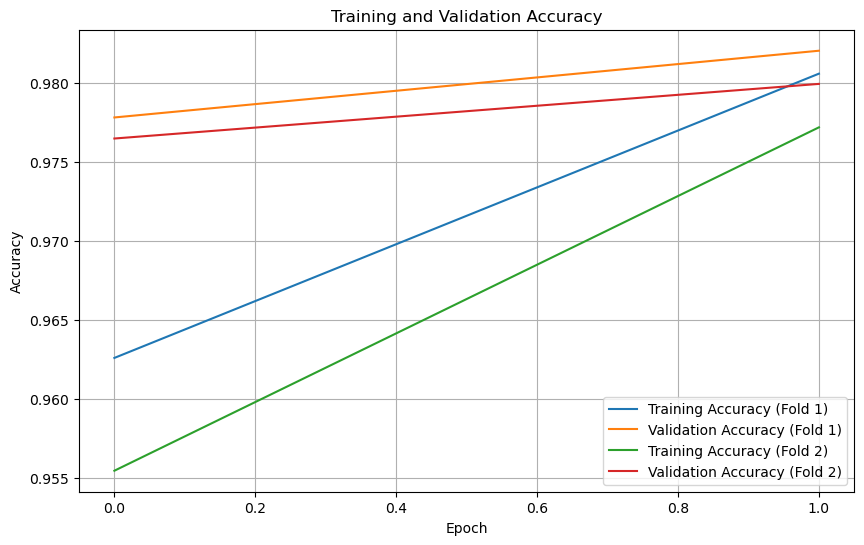

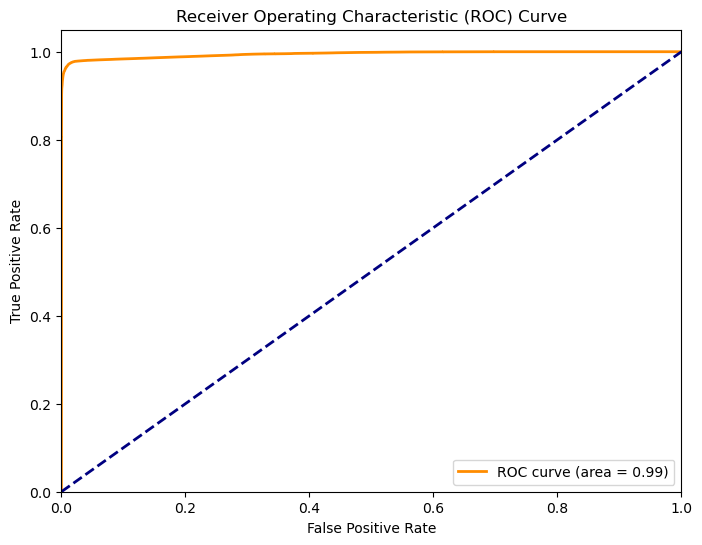

In [16]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout, Input, Layer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import time
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras import backend as K

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values

# Get the input shape
input_shape = X.shape
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 2

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Custom Attention layer
class Attention(Layer):
    def __init__(self, return_sequences=True, **kwargs):
        self.return_sequences = return_sequences
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Alignment scores
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        
        # Weighted sum
        output = x * a
        
        if self.return_sequences:
            return output
        else:
            return K.sum(output, axis=1)

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the CNN-LSTM Model with Attention
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], 1)))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64, return_sequences=True))
    model.add(Attention(return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Generate the model architecture image
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    print('Model architecture saved as model_architecture.png')
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                       epochs=2, batch_size=32, validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0,0], cm[0,1]])
    table.add_row(["Actual Positive", cm[1,0], cm[1,1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')

In [ ]:
#CNN-Bi-LSTM-attention_mechanism
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Flatten, Dropout, Input, Layer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import time
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras import backend as K

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values

# Get the input shape
input_shape = X.shape
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 5

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Custom Attention layer
class Attention(Layer):
    def __init__(self, return_sequences=True, **kwargs):
        self.return_sequences = return_sequences
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Alignment scores
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        
        # Weighted sum
        output = x * a
        
        if self.return_sequences:
            return output
        else:
            return K.sum(output, axis=1)

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the CNN-BiLSTM Model with Attention
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], 1)))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Attention(return_sequences=True))
    model.add(Dropout(0.2))
    model.add(Bidirectional(LSTM(32)))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Generate the model architecture image
   # plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
   # print('Model architecture saved as model_architecture.png')
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                       epochs=10, batch_size=32, validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0,0], cm[0,1]])
    table.add_row(["Actual Positive", cm[1,0], cm[1,1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')

Input shape: (2323670, 12)
Fold 1/5
Model Summary:


Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 10, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 5, 128)              │          49,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_1 (Attention)              │ (None, 5, 128)              │             133 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

In [11]:
#Transformer model 

import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Layer, LayerNormalization, Embedding, MultiHeadAttention, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import time
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras import backend as K

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values.astype(int)  # Convert y to integers

# Get the input shape
input_shape = X.shape[1]
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 2

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Transformer layer
class TransformerLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerLayer, self).__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.dff = dff
        self.rate = rate

        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)

        self.dense1 = Dense(dff, activation='relu')
        self.dense2 = Dense(d_model)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.mha(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.dense1(out1)
        ffn_output = self.dropout1(ffn_output, training=training)
        ffn_output = self.dense2(ffn_output)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

# Define the Transformer model
def build_transformer_model(input_shape, d_model=64, num_heads=4, dff=256, num_layers=2):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    model.add(Embedding(input_dim=input_shape, output_dim=d_model))

    for _ in range(num_layers):
        model.add(TransformerLayer(d_model, num_heads, dff))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the Transformer model
    model = build_transformer_model(input_shape)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Generate the model architecture image
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    print('Model architecture saved as model_architecture.png')
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train, y_train,
                       epochs=2, batch_size=32, validation_data=(X_test, y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test)
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0,0], cm[0,1]])
    table.add_row(["Actual Positive", cm[1,0], cm[1,1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred.ravel())
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')

Input shape: 12
Fold 1/2
Model Summary:


Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)              │ (None, 12, 64)              │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_layer_18                 │ (None, 12, 64)              │          49,984 │
│ (TransformerLayer)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_layer_19                 │ (None, 12, 64)              │          49,984 │
│ (TransformerLayer)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

C:\Users\NK\anaconda3_11\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Specificity: 1.0000
Confusion Matrix:
+-----------------+--------------------+--------------------+
|                 | Predicted Negative | Predicted Positive |
+-----------------+--------------------+--------------------+
| Actual Negative |       580513       |         0          |
| Actual Positive |       581322       |         0          |
+-----------------+--------------------+--------------------+
ROC AUC: 0.5000
Test Loss: 0.6932, Test Accuracy: 0.4997
Fold 2/2
Model Summary:


Model: "sequential_2"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)             │ (None, 12, 64)              │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_layer_20                 │ (None, 12, 64)              │          49,984 │
│ (TransformerLayer)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_layer_21                 │ (None, 12, 64)              │          49,984 │
│ (TransformerLayer)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

KeyboardInterrupt: 

In [17]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Layer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import time
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras import backend as K

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values.astype(int)  # Convert y to integers

# Get the input shape
input_shape = X.shape[1]
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 2

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Define the Capsule Network model
def build_capsule_network(input_shape, num_classes):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the Capsule Network model
    model = build_capsule_network(input_shape, num_classes=2)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Generate the model architecture image
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    print('Model architecture saved as model_architecture.png')
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train, y_train,
                       epochs=2, batch_size=32, validation_data=(X_test, y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test)
    y_pred_binary = np.argmax(y_pred, axis=1)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0,0], cm[0,1]])
    table.add_row(["Actual Positive", cm[1,0], cm[1,1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred[:,1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')

Input shape: 12
Fold 1/2
Model Summary:


Model: "sequential_8"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                     │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_81 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
 Total params: 962 (3.76 KB)
 Trainable params: 962 (3.76 KB)
 Non-trainable params: 0 (0.00 B)


Model architecture saved as model_architecture.png
Epoch 1/2
36308/36308 ━━━━━━

Model: "sequential_9"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                     │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_82 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
 Total params: 962 (3.76 KB)
 Trainable params: 962 (3.76 KB)
 Non-trainable params: 0 (0.00 B)


Model architecture saved as model_architecture.png
Epoch 1/2
36308/36308 ━━━━━━

KeyboardInterrupt: 

In [8]:
/kaggle/input/final-clean-sampl-norm-balance-shuff-nf-uq-nids1/Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv

Input shape: 12
Fold 1/5
Model Summary:


Model: "sequential_9"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ (None, 128)                 │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

KeyboardInterrupt: 

In [4]:
# Check for overfitting
if history.history['val_loss'][-1] > history.history['loss'][-1]:
    print("Overfitting detected!")
else:
    print("No overfitting detected.")

No overfitting detected.


In [2]:
pip install optuna

   ---------------------------------------- 0.0/380.1 kB ? eta -:--:--
   --- ------------------------------------ 30.7/380.1 kB 1.3 MB/s eta 0:00:01
   --- ------------------------------------ 30.7/380.1 kB 1.3 MB/s eta 0:00:01
   ------ -------------------------------- 61.4/380.1 kB 544.7 kB/s eta 0:00:01
   ---------- --------------------------- 102.4/380.1 kB 653.6 kB/s eta 0:00:01
   -------------- ----------------------- 143.4/380.1 kB 708.1 kB/s eta 0:00:01
   ---------------------- --------------- 225.3/380.1 kB 981.9 kB/s eta 0:00:01
   ------------------------- ------------ 256.0/380.1 kB 923.9 kB/s eta 0:00:01
   ------------------------------- ------ 317.4/380.1 kB 981.5 kB/s eta 0:00:01
   ------------------------------- ------ 317.4/380.1 kB 981.5 kB/s eta 0:00:01
   ------------------------------- ------ 317.4/380.1 kB 981.5 kB/s eta 0:00:01
   ------------------------------- ------ 317.4/380.1 kB 981.5 kB/s eta 0:00:01
   --------------------------------- ---- 337.9/380

In [3]:
import optuna

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Load the dataset from a CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')  # Replace 'your_dataset.csv' with your actual file path

# Separate features and labels (if applicable)
# Assuming the last column is the label; adjust as necessary
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values    # Labels (if you have them)

# Standardize the features
X_scaled = StandardScaler().fit_transform(X)

# Create a t-SNE model and fit it to the data
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Create a scatter plot of the t-SNE results
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.7)

# Add a color bar if labels are available
if y is not None:
    plt.colorbar(scatter)

plt.title('t-SNE Plot of the Dataset')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid()
plt.show()

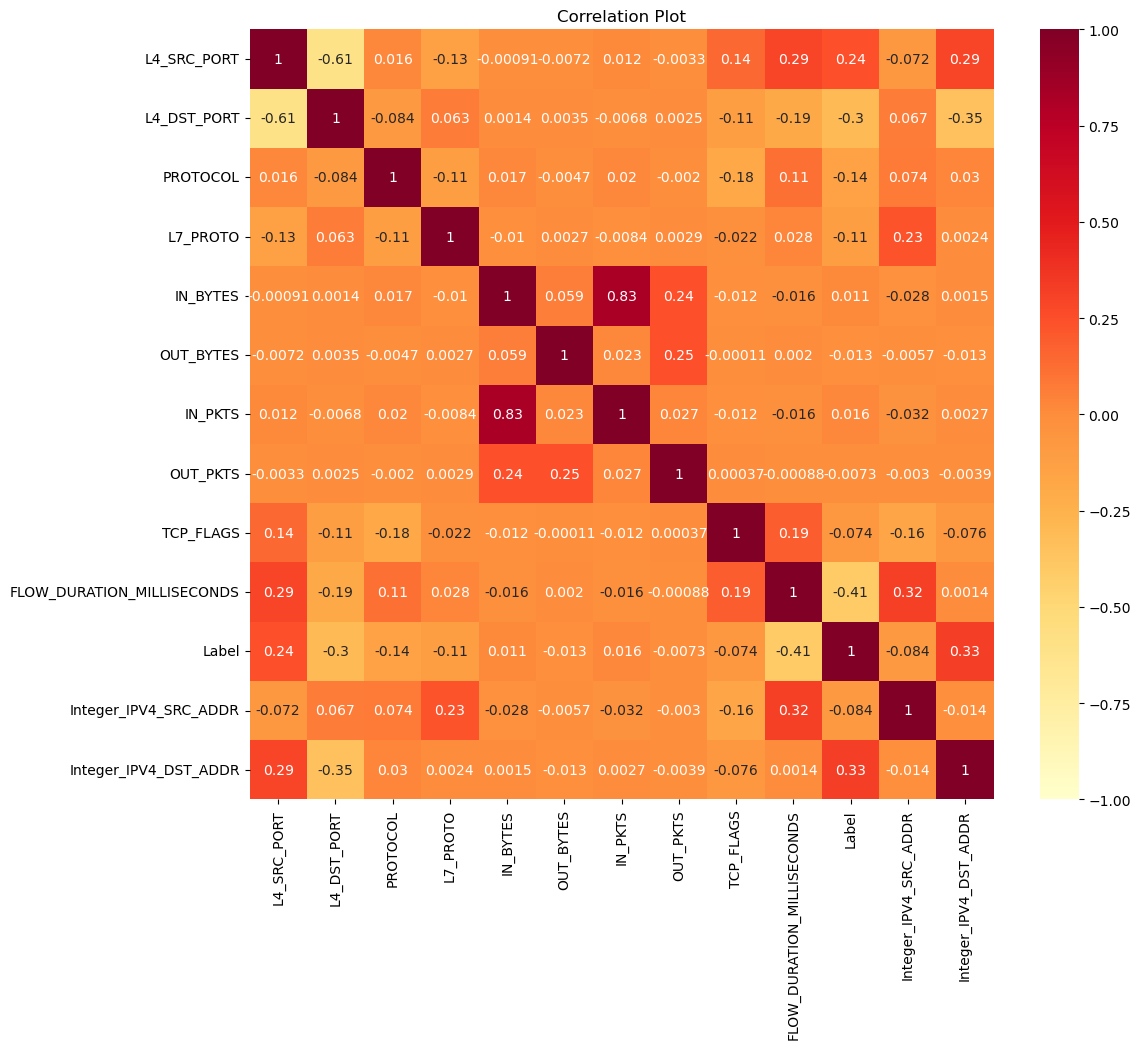

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset from a CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')  # Replace 'your_dataset.csv' with your actual file path

# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a correlation plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', vmin=-1, vmax=1)
plt.title('Correlation Plot')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


In [10]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Layer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras.callbacks import Callback, LearningRateScheduler
from tensorflow.keras import backend as K

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values.astype(int)  # Convert y to integers

# Get the input shape
input_shape = X.shape[1]
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 5

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Define the symbolic reasoning layer
class SymbolicReasoningLayer(Layer):
    def __init__(self, num_symbols, **kwargs):
        super(SymbolicReasoningLayer, self).__init__(**kwargs)
        self.num_symbols = num_symbols

    def build(self, input_shape):
        self.W = self.add_weight(name='W',
                                 shape=(input_shape[-1], self.num_symbols),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='b',
                                 shape=(self.num_symbols,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs, training=None):
        # Symbolic reasoning logic
        outputs = tf.matmul(inputs, self.W) + self.b
        outputs = tf.nn.softmax(outputs)
        return outputs

# Define the Neuro-Symbolic AI model
def build_neuro_symbolic_model(input_shape, num_classes):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(SymbolicReasoningLayer(num_symbols=20))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# Define the cyclical learning rate schedule function
def cyclical_learning_rate(epoch, base_lr=0.001, max_lr=0.006, step_size=2000):
    cycle = np.floor(1 + epoch / (2 * step_size))
    x = np.abs(epoch / step_size - 2 * cycle + 1)
    return base_lr + (max_lr - base_lr) * np.maximum(0, (1 - x))

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the Neuro-Symbolic AI model
    model = build_neuro_symbolic_model(input_shape, num_classes=2)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Initialize the learning rate scheduler
    lr_scheduler = LearningRateScheduler(lambda epoch: cyclical_learning_rate(epoch, base_lr=0.001, max_lr=0.006, step_size=5), verbose=1)
    
    # Train the model with cyclical learning rate
    history = model.fit(X_train, y_train,
                        epochs=10, batch_size=32, validation_data=(X_test, y_test), 
                        callbacks=[lr_scheduler], verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test)
    y_pred_binary = np.argmax(y_pred, axis=1)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0, 0], cm[0, 1]])
    table.add_row(["Actual Positive", cm[1, 0], cm[1, 1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot training and validation loss and accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i + 1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i + 1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i + 1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i + 1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')


Input shape: 12
Fold 1/5

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 153s 2ms/step - accuracy: 0.9569 - loss: 0.1301 - val_accuracy: 0.9842 - val_loss: 0.0622 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.002.
Epoch 2/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 141s 2ms/step - accuracy: 0.9793 - loss: 0.0763 - val_accuracy: 0.9841 - val_loss: 0.0632 - learning_rate: 0.0020

Epoch 3: LearningRateScheduler setting learning rate to 0.0029999999999999996.
Epoch 3/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 135s 2ms/step - accuracy: 0.9802 - loss: 0.0747 - val_accuracy: 0.9846 - val_loss: 0.0618 - learning_rate: 0.0030

Epoch 4: LearningRateScheduler setting learning rate to 0.004.
Epoch 4/10
58092/58092 ━━━━━━━━━━━━━━━━━━━━ 125s 2ms/step - accuracy: 0.9798 - loss: 0.0763 - val_accuracy: 0.9840 - val_loss: 0.0623 - learning_rate: 0.0040

Epoch 5: LearningRateScheduler setting learning rate to 0.005.
Epoch 5

KeyboardInterrupt: 

The main changes are:
Importing the LearningRateScheduler from tensorflow.keras.callbacks.
Defining a step_decay function that implements a cyclical learning rate scheduler. In this example, the learning rate decreases by a factor of drop every epochs_drop epochs.
Modifying the model compilation to use the Adam optimizer without specifying the learning rate.
Defining the cyclical learning rate scheduler using LearningRateScheduler and passing it as a callback to model.fit().
Removing the learning_rate parameter from the Adam optimizer in the model compilation.
This implementation uses a step decay cyclical learning rate scheduler, where the learning rate starts at an initial value and decreases by a factor of drop every epochs_drop epochs. You can experiment with different cyclical learning rate policies, such as triangular or exponential, by modifying the step_decay function accordingly.
By integrating cyclical learning rates, your Neuro-Symbolic AI model can potentially benefit from improved convergence and better performance. The cyclical learning rate allows the model to explore different regions of the loss landscape, potentially escaping local minima and achieving faster convergence

In [11]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Layer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import backend as K

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values.astype(int)  # Convert y to integers

# Get the input shape
input_shape = X.shape[1]
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 5

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Define the symbolic reasoning layer
class SymbolicReasoningLayer(Layer):
    def __init__(self, num_symbols, **kwargs):
        super(SymbolicReasoningLayer, self).__init__(**kwargs)
        self.num_symbols = num_symbols

    def build(self, input_shape):
        self.W = self.add_weight(name='W',
                                 shape=(input_shape[-1], self.num_symbols),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='b',
                                 shape=(self.num_symbols,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs, training=None):
        # Symbolic reasoning logic
        outputs = tf.matmul(inputs, self.W) + self.b
        outputs = tf.nn.softmax(outputs)
        return outputs

# Define the Neuro-Symbolic AI model
def build_neuro_symbolic_model(input_shape, num_classes):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(SymbolicReasoningLayer(num_symbols=20))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# Define the triangular cyclical learning rate scheduler
class TriangularCyclicLR(Callback):
    def __init__(self, base_learning_rate=0.001, max_learning_rate=0.006, step_size=2000):
        super(TriangularCyclicLR, self).__init__()
        self.base_learning_rate = base_learning_rate
        self.max_learning_rate = max_learning_rate
        self.step_size = step_size
        self.iteration = 0

    def on_train_begin(self, logs=None):
        self.iteration = 0

    def on_epoch_end(self, epoch, logs=None):
        self.iteration += 1
        cycle = np.floor(1 + self.iteration / (2 * self.step_size))
        x = np.abs(self.iteration / self.step_size - 2 * cycle + 1)
        learning_rate = self.base_learning_rate + (self.max_learning_rate - self.base_learning_rate) * np.maximum(0, (1 - x))
        
        K.set_value(self.model.optimizer.learning_rate, learning_rate)
        print(f"\nEpoch {epoch + 1}: Learning Rate is set to {learning_rate:.6f}")

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the Neuro-Symbolic AI model
    model = build_neuro_symbolic_model(input_shape, num_classes=2)
    
    # Compile the model with cyclical learning rate
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Initialize the triangular cyclical learning rate scheduler
    cyclic_lr = TriangularCyclicLR()
    
    # Train the model with cyclical learning rate
    history = model.fit(X_train, y_train,
                        epochs=10, batch_size=32, validation_data=(X_test, y_test), 
                        callbacks=[cyclic_lr], verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test)
    y_pred_binary = np.argmax(y_pred, axis=1)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0, 0], cm[0, 1]])
    table.add_row(["Actual Positive", cm[1, 0], cm[1, 1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot training and validation loss and accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i + 1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i + 1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i + 1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i + 1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')


Input shape: 12
Fold 1/5
Epoch 1/10
58068/58092 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9578 - loss: 0.1296

AttributeError: 'str' object has no attribute 'name'

Input shape: 12
Fold 1/2
Model Summary:


Model: "sequential_12"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                     │ (None, 128)                 │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_48 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

Model: "sequential_13"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                     │ (None, 128)                 │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_52 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_53 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────

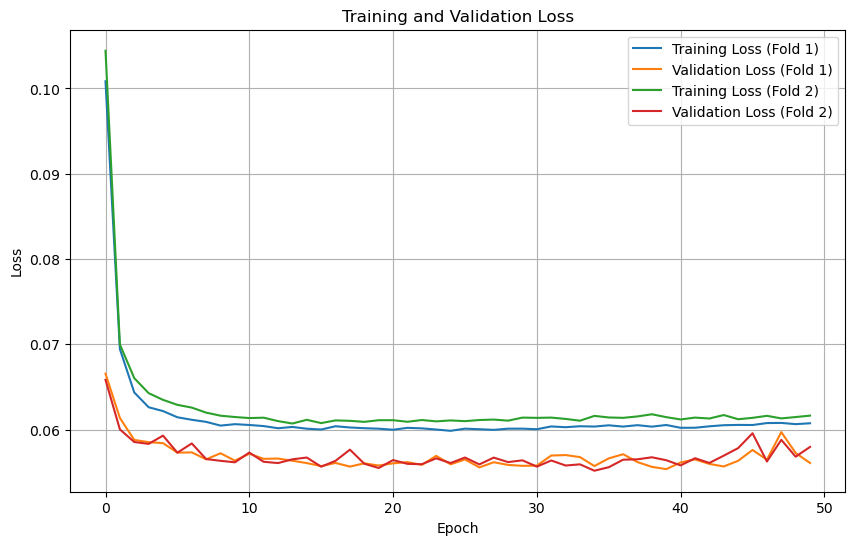

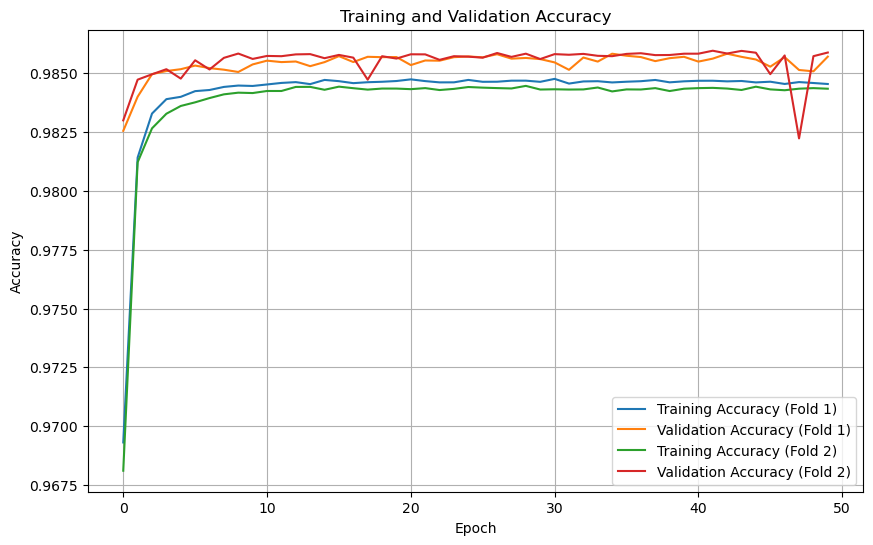

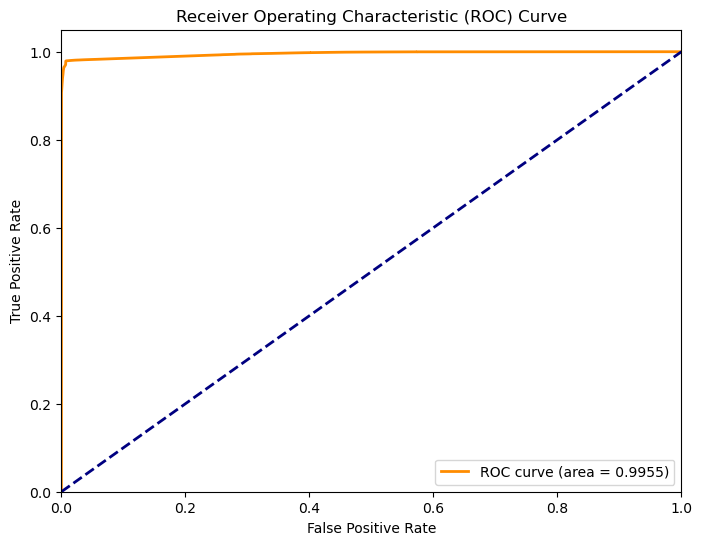

In [12]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Layer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from tensorflow.keras import backend as K

# Read the CSV file
df = pd.read_csv('Final_clean_sampl_norm_balance_shuff_NF-UQ-NIDS.csv')

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values.astype(int)  # Convert y to integers

# Get the input shape
input_shape = X.shape[1]
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 2

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Define the symbolic reasoning layer
class SymbolicReasoningLayer(Layer):
    def __init__(self, num_symbols, **kwargs):
        super(SymbolicReasoningLayer, self).__init__(**kwargs)
        self.num_symbols = num_symbols

    def build(self, input_shape):
        self.W = self.add_weight(name='W',
                                 shape=(input_shape[-1], self.num_symbols),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='b',
                                 shape=(self.num_symbols,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs, training=None):
        # Symbolic reasoning logic
        outputs = tf.matmul(inputs, self.W) + self.b
        outputs = tf.nn.softmax(outputs)
        return outputs

# Define the Neuro-Symbolic AI model
def build_neuro_symbolic_model(input_shape, num_classes):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(SymbolicReasoningLayer(num_symbols=20))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the Neuro-Symbolic AI model
    model = build_neuro_symbolic_model(input_shape, num_classes=2)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Start the timer
    start_time = time.time()
    
    # Train the model for a fixed number of epochs
    history = model.fit(X_train, y_train,
                        epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test)
    y_pred_binary = np.argmax(y_pred, axis=1)
    
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Negative", "Predicted Positive"]
    table.add_row(["Actual Negative", cm[0, 0], cm[0, 1]])
    table.add_row(["Actual Positive", cm[1, 0], cm[1, 1]])
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i + 1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i + 1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i + 1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i + 1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')


#multiclass classification

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Layer
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import time


In [9]:

# Step 1: Read the CSV file into a pandas DataFrame
df = pd.read_csv('multiclass_label_encoded_dataset.csv')  # Replace with your actual file name

# Step 2: Drop specific columns (replace with actual column names you want to drop)
columns_to_drop = ['Label', 'Attack']  # Replace with the names of the columns you want to drop
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # Drop the specified columns

# Step 3: Separate the features (X) and the target variable (y)
X = df.drop(columns=['Attack_Encoded']).values  # Replace 'Attack_Encoded' with your actual target column
y = df['Attack_Encoded'].values.astype(int)  # Convert y to integers

# Step 4: Ensure labels are zero-indexed
# If your labels are from 1 to 21, adjust them to be zero-indexed
y = y - 1  # Adjust labels to be 0-indexed (0 to 20)

# Step 5: Convert to appropriate types
X = X.astype(np.float32)  # Convert features to float32
y = y.astype(np.int32)     # Convert labels to int32

# Step 6: Check for NaN or infinite values
if np.any(np.isnan(X)) or np.any(np.isinf(X)):
    raise ValueError("Input data contains NaN or infinite values.")

# Step 7: Get the input shape and number of classes
input_shape = X.shape[1]
num_classes = len(np.unique(y))  # Determine the number of classes (should be 21)
print("Input shape:", input_shape)
print("Number of classes:", num_classes)

# Step 8: Define the number of folds for cross-validation
n_folds = 2  # You can increase this for better validation

# Step 9: Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Step 10: Define the symbolic reasoning layer
class SymbolicReasoningLayer(Layer):
    def __init__(self, num_symbols, **kwargs):
        super(SymbolicReasoningLayer, self).__init__(**kwargs)
        self.num_symbols = num_symbols

    def build(self, input_shape):
        self.W = self.add_weight(name='W',
                                 shape=(input_shape[-1], self.num_symbols),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='b',
                                 shape=(self.num_symbols,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs, training=None):
        # Symbolic reasoning logic
        outputs = tf.matmul(inputs, self.W) + self.b
        outputs = tf.nn.softmax(outputs)  # Softmax activation for symbolic reasoning
        return outputs

# Step 11: Define the Neuro-Symbolic AI model
def build_neuro_symbolic_model(input_shape, num_classes):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    model.add(Dense(128, activation='relu'))  # Use ReLU activation
    model.add(Dropout(0.3))  # Dropout for regularization
    model.add(Dense(128, activation='relu'))  # Use ReLU activation
    model.add(Dropout(0.3))
    model.add(SymbolicReasoningLayer(num_symbols=20))  # Custom symbolic reasoning layer
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))  # Use ReLU activation
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))  # Softmax for output layer
    return model

# Step 12: Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the Neuro-Symbolic AI model
    model = build_neuro_symbolic_model(input_shape, num_classes)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary()
    
    # Start the timer
    start_time = time.time()
    
    # Train the model for a fixed number of epochs
    history = model.fit(X_train, y_train,
                        epochs=10,  # Increase the number of epochs for better training
                        batch_size=32, 
                        validation_data=(X_test, y_test), 
                        verbose=2)
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test)
    y_pred_binary = np.argmax(y_pred, axis=1)
    
    precision = precision_score(y_test, y_pred_binary, average='weighted')  # Use weighted for multiclass
    recall = recall_score(y_test, y_pred_binary, average='weighted')
    f1 = f1_score(y_test, y_pred_binary, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Class 0", "Predicted Class 1", "Predicted Class 2", "Predicted Class 3", "Predicted Class 4", "Predicted Class 5", "Predicted Class 6", "Predicted Class 7", "Predicted Class 8", "Predicted Class 9", "Predicted Class 10", "Predicted Class 11", "Predicted Class 12", "Predicted Class 13", "Predicted Class 14", "Predicted Class 15", "Predicted Class 16", "Predicted Class 17", "Predicted Class 18", "Predicted Class 19"]
    for i in range(num_classes):
        table.add_row([f"Actual Class {i}"] + list(cm[i, :]))
    print(table)

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Optional: Add plotting code if needed


Input shape: 12
Number of classes: 20
Fold 1/2
Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ symbolic_reasoning_layer_2           │ (None, 20)                  │           2,580 │
│ (SymbolicReasoningLayer)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 20)                  │           2,580 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,024 (101.66 KB)

 Trainable params: 26,024 (101.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
97545/97545 - 327s - 3ms/step - accuracy: 0.0702 - loss: 2.9725 - val_accuracy: 0.1018 - val_loss: 2.9502
Epoch 2/10
97545/97545 - 285s - 3ms/step - accuracy: 0.0703 - loss: 2.9724 - val_accuracy: 0.1018 - val_loss: 2.9491
Epoch 3/10


KeyboardInterrupt: 

In [ ]:


# Read the CSV file
df = pd.read_csv('multiclass_label_encoded_dataset.csv')  # Replace with your actual file name

# Separate the features (X) and the target variable (y)
X = df.drop(columns=['Label']).values
y = df['Label'].values

# One-hot encode the labels for multiclass classification
y = to_categorical(y, num_classes=20)  # Ensure you specify the number of classes

# Get the input shape
input_shape = X.shape
print("Input shape:", input_shape)

# Define the number of folds for cross-validation
n_folds = 2

# Initialize the k-fold cross-validation
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize lists to store the training and validation loss and accuracy histories
train_loss_histories = []
val_loss_histories = []
train_acc_histories = []
val_acc_histories = []

# Perform k-fold cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{n_folds}")
    
    # Split the data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Define the CNN-Bi-LSTM model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], 1)))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Bidirectional(LSTM(64, return_sequences=True, activation='relu')))
    model.add(Dropout(0.2))
    model.add(Bidirectional(LSTM(32, activation='relu')))
    model.add(Dropout(0.2))
    model.add(Dense(20, activation='softmax'))  # Change to 20 classes with softmax activation
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Print the model summary
    print("Model Summary:")
    model.summary(print_fn=lambda x: print(x, end="\n\n"))
    
    # Generate the model architecture image
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    print('Model architecture saved as model_architecture.png')
    
    # Start the timer
    start_time = time.time()
    
    # Train the model
    history = model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train,
                       epochs=1, batch_size=32, validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test), verbose=1)
    
    # Append the training and validation loss and accuracy histories
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    train_acc_histories.append(history.history['accuracy'])
    val_acc_histories.append(history.history['val_accuracy'])
    
    # Calculate the elapsed time
    elapsed_time = time.time() - start_time
    
    # Calculate the time remaining
    total_time = elapsed_time * n_folds / (fold + 1)
    time_remaining = total_time - elapsed_time
    
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Estimated time remaining: {time_remaining:.2f} seconds")
    
    # Evaluate the model on the test set for the current fold
    y_pred = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))
    y_pred_binary = np.argmax(y_pred, axis=1)
    y_test_binary = np.argmax(y_test, axis=1)  # Convert one-hot back to class labels for evaluation
    
    precision = precision_score(y_test_binary, y_pred_binary, average='weighted')
    recall = recall_score(y_test_binary, y_pred_binary, average='weighted')
    f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # Print the confusion matrix using PrettyTable
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    table = PrettyTable()
    table.field_names = ["", "Predicted Class 0", "Predicted Class 1", "Predicted Class 2", "Predicted Class 3", "Predicted Class 4", "Predicted Class 5", "Predicted Class 6", "Predicted Class 7", "Predicted Class 8", "Predicted Class 9", "Predicted Class 10", "Predicted Class 11", "Predicted Class 12", "Predicted Class 13", "Predicted Class 14", "Predicted Class 15", "Predicted Class 16", "Predicted Class 17", "Predicted Class 18", "Predicted Class 19"]
    for i in range(20):
        table.add_row([f"Actual Class {i}"] + list(cm[i, :]))
    print(table)
    
    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_binary)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    test_loss, test_accuracy = model.evaluate(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot the training and validation loss histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_loss_histories[i], label=f'Training Loss (Fold {i+1})')
    plt.plot(val_loss_histories[i], label=f'Validation Loss (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
print('Loss plot saved as loss_plot.png')

# Plot the training and validation accuracy histories
plt.figure(figsize=(10, 6))
for i in range(n_folds):
    plt.plot(train_acc_histories[i], label=f'Training Accuracy (Fold {i+1})')
    plt.plot(val_acc_histories[i], label=f'Validation Accuracy (Fold {i+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
print('Accuracy plot saved as accuracy_plot.png')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_plot.png')
print('ROC plot saved as roc_plot.png')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load your datasets
df_normalized = pd.read_csv('normalized_dataset.csv')  # Replace with your normalized dataset file
df_original = pd.read_csv('original_dataset.csv')      # Replace with your original dataset file

# Separate the features (X) and the target variable (y) for both datasets
X_normalized = df_normalized.drop(columns=['Label']).values  # Adjust 'Label' as necessary
y_normalized = df_normalized['Label'].values

X_original = df_original.drop(columns=['Label']).values      # Adjust 'Label' as necessary
y_original = df_original['Label'].values

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot before normalization (original dataset)
scatter1 = ax1.scatter(X_original[:, 0], X_original[:, 1], c=y_original, cmap='viridis', alpha=0.6)
ax1.set_title('Before Normalization')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend(*scatter1.legend_elements(), title="Classes")

# Plot after normalization (normalized dataset)
scatter2 = ax2.scatter(X_normalized[:, 0], X_normalized[:, 1], c=y_normalized, cmap='viridis', alpha=0.6)
ax2.set_title('After Normalization')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend(*scatter2.legend_elements(), title="Classes")

plt.tight_layout()
plt.savefig('normalization_comparison_plot.png')
print('Normalization comparison plot saved as normalization_comparison_plot.png')
plt.show()


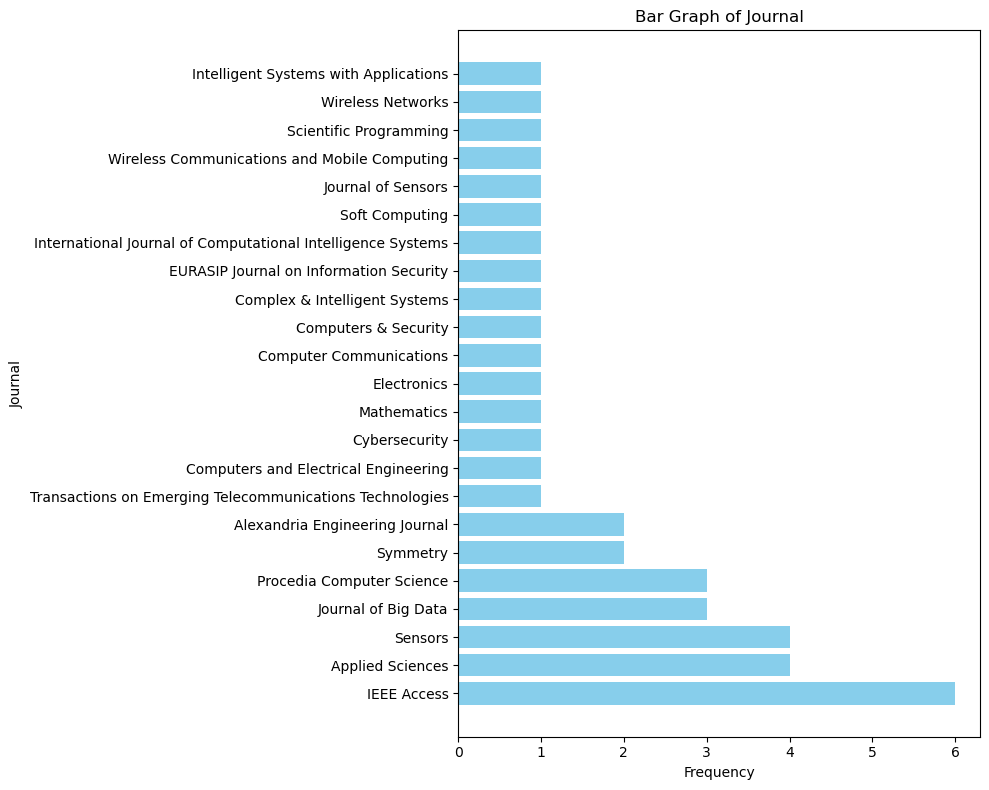

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the dataset with a specified encoding
# Try using 'ISO-8859-1' or 'Windows-1252' if 'utf-8' fails
df = pd.read_csv('DE.csv', encoding='ISO-8859-1')  # Replace with your actual file name

# Step 2: Select the column to plot
# Replace 'ColumnName' with the actual name of the column you want to plot
column_to_plot = 'Journal'  # Change this to your specific column name

# Step 3: Count the occurrences of each unique value in the column
value_counts = df[column_to_plot].value_counts()

# Step 4: Create a horizontal bar graph
plt.figure(figsize=(10, 8))
plt.barh(value_counts.index, value_counts, color='skyblue')  # Use plt.barh() for horizontal bars
plt.title(f'Bar Graph of {column_to_plot}')
plt.ylabel(column_to_plot)
plt.xlabel('Frequency')
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.savefig('bar_graph.png')  # Save the plot as a PNG file
plt.show()  # Display the plot


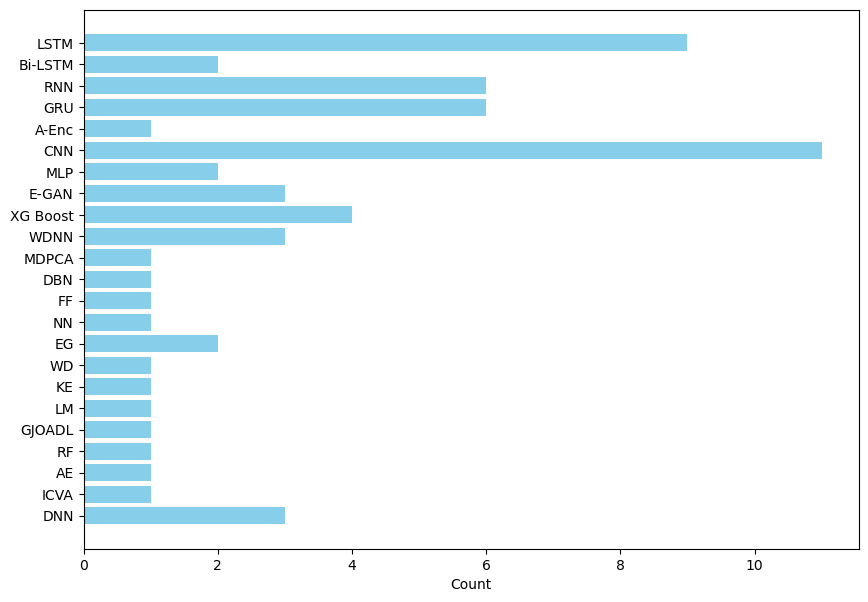

In [16]:
import matplotlib.pyplot as plt

# Data
techniques = ['LSTM', 'Bi-LSTM', 'RNN', 'GRU', 'A-Enc', 'CNN', 'MLP', 'E-GAN', 'XG Boost', 'WDNN', 'MDPCA', 'DBN', 'FF', 'NN', 'EG', 'WD', 'KE', 'LM', 'GJOADL', 'RF', 'AE', 'ICVA', 'DNN']
counts = [9, 2, 6, 6, 1, 11, 2, 3, 4, 3, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 3]

# Create bar chart
plt.figure(figsize=(10, 7))
plt.barh(techniques, counts, color='skyblue')
plt.xlabel('Count')
#plt.title('Frequency of Techniques in Research Studies')
plt.gca().invert_yaxis()  # To display the highest counts at the top
plt.show()


C:\Users\NK\AppData\Local\Temp\ipykernel_9616\1283998010.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datasets, rotation=45, ha='right')


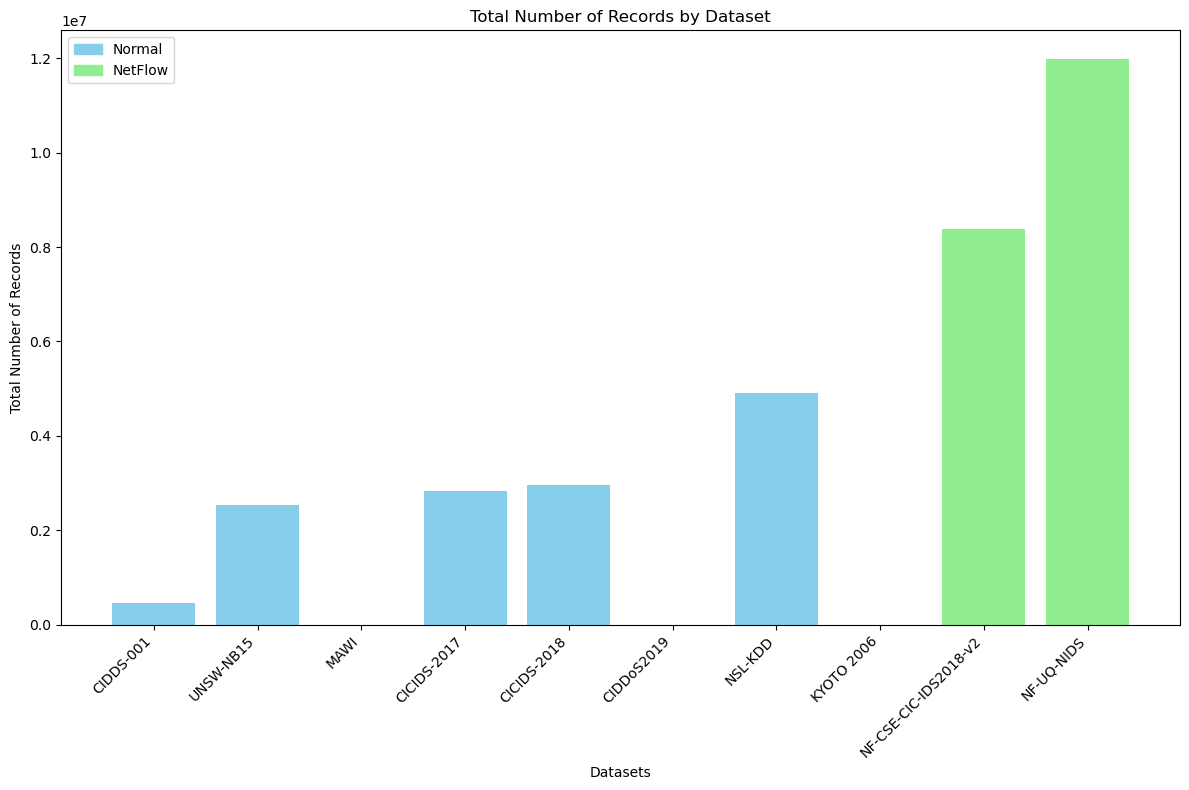

In [17]:
import matplotlib.pyplot as plt

# Data
datasets = [
    'CIDDS-001', 'UNSW-NB15', 'MAWI', 'CICIDS-2017', 'CICIDS-2018',
    'CIDDoS2019', 'NSL-KDD', 'KYOTO 2006', 'NF-CSE-CIC-IDS2018-v2', 'NF-UQ-NIDS'
]
records = [
    457590, 2540044, None, 2830743, 2954455, None, 4898431, None, 8392401, 11994893
]
types = [
    'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 
    'Normal', 'Normal', 'Normal', 'NetFlow', 'NetFlow'
]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = {'Normal':'skyblue', 'NetFlow':'lightgreen'}

# Create bar chart
bars = ax.bar(datasets, [r if r else 0 for r in records], color=[colors[t] for t in types])
ax.set_xlabel('Datasets')
ax.set_ylabel('Total Number of Records')
ax.set_title('Total Number of Records by Dataset')
ax.set_xticklabels(datasets, rotation=45, ha='right')

# Add legend
ax.legend(handles=[plt.Rectangle((0,0),1,1, color=colors['Normal']), 
                    plt.Rectangle((0,0),1,1, color=colors['NetFlow'])],
          labels=['Normal', 'NetFlow'])

plt.tight_layout()
plt.show()


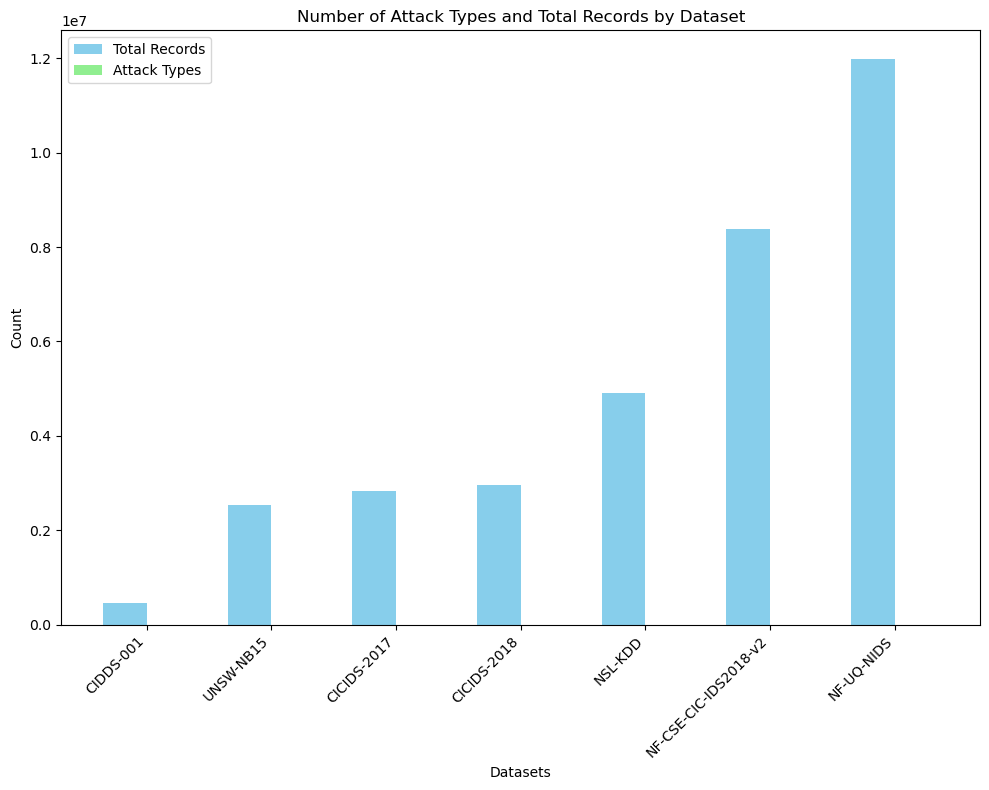

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Updated Data
datasets = [
    'CIDDS-001', 'UNSW-NB15', 'CICIDS-2017', 'CICIDS-2018',
    'NSL-KDD', 'NF-CSE-CIC-IDS2018-v2', 'NF-UQ-NIDS'
]
records = [
    457590, 2540044, 2830743, 2954455,
    4898431, 8392401, 11994893
]
attack_types = [
    10, 9, 11, 11,
    22, 8, 21
]

x = np.arange(len(datasets))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 8))

# Bars for Total Records
bars1 = ax.bar(x - width/2, records, width, label='Total Records', color='skyblue')

# Bars for Number of Attack Types
bars2 = ax.bar(x + width/2, attack_types, width, label='Attack Types', color='lightgreen')

ax.set_xlabel('Datasets')
ax.set_ylabel('Count')
ax.set_title('Number of Attack Types and Total Records by Dataset')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()


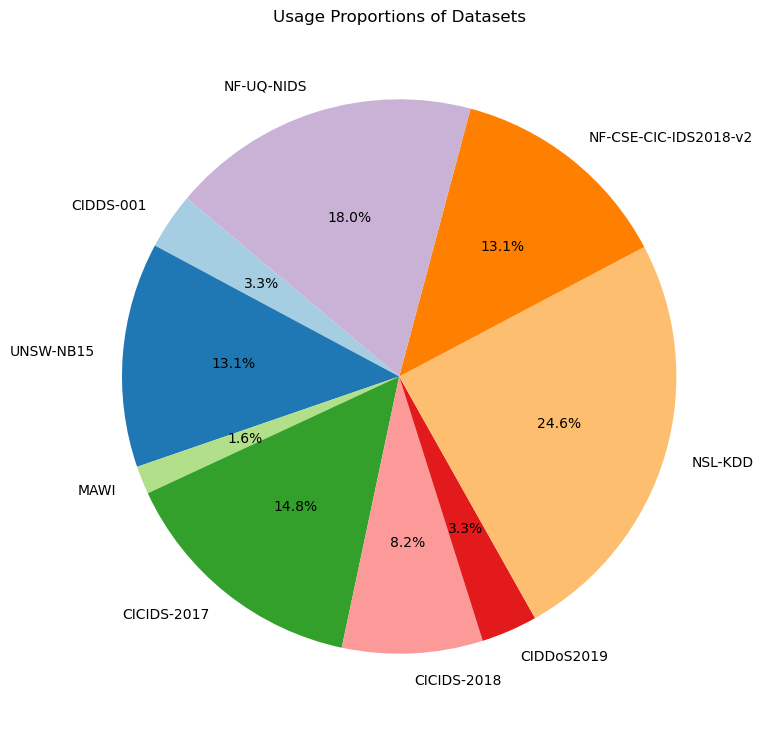

In [22]:
import matplotlib.pyplot as plt

# Updated Data
datasets = [
    'CIDDS-001', 'UNSW-NB15', 'MAWI', 'CICIDS-2017', 'CICIDS-2018',
    'CIDDoS2019', 'NSL-KDD', 'NF-CSE-CIC-IDS2018-v2', 'NF-UQ-NIDS'
]
usage_counts = [
    2, 8, 1, 9, 5, 2, 15, 8, 11  # Removed the count for 'KYOTO 2006'
]

# Plotting the pie chart
fig, ax = plt.subplots(figsize=(11, 9))

# Pie chart
ax.pie(usage_counts, labels=datasets, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(datasets))))
ax.set_title('Usage Proportions of Datasets')

plt.show()


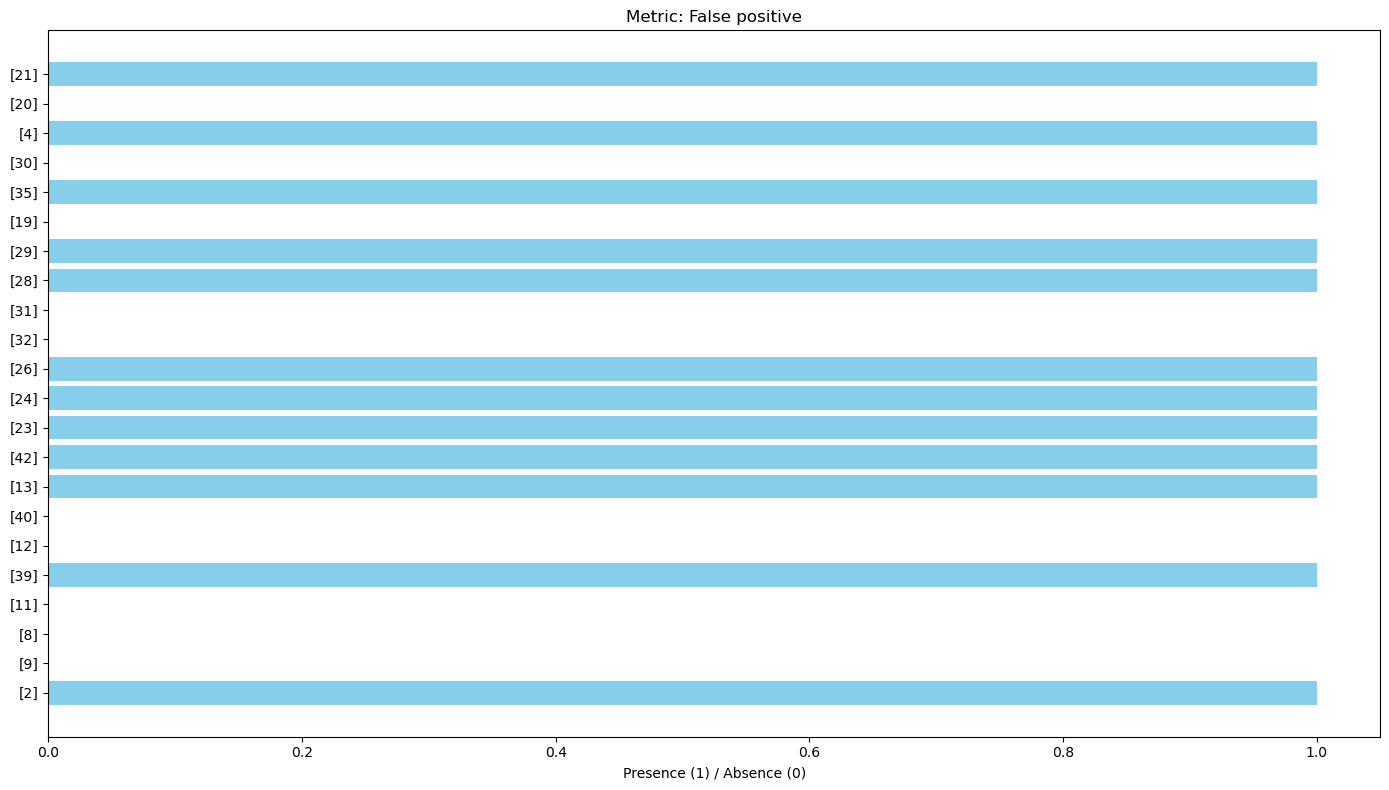

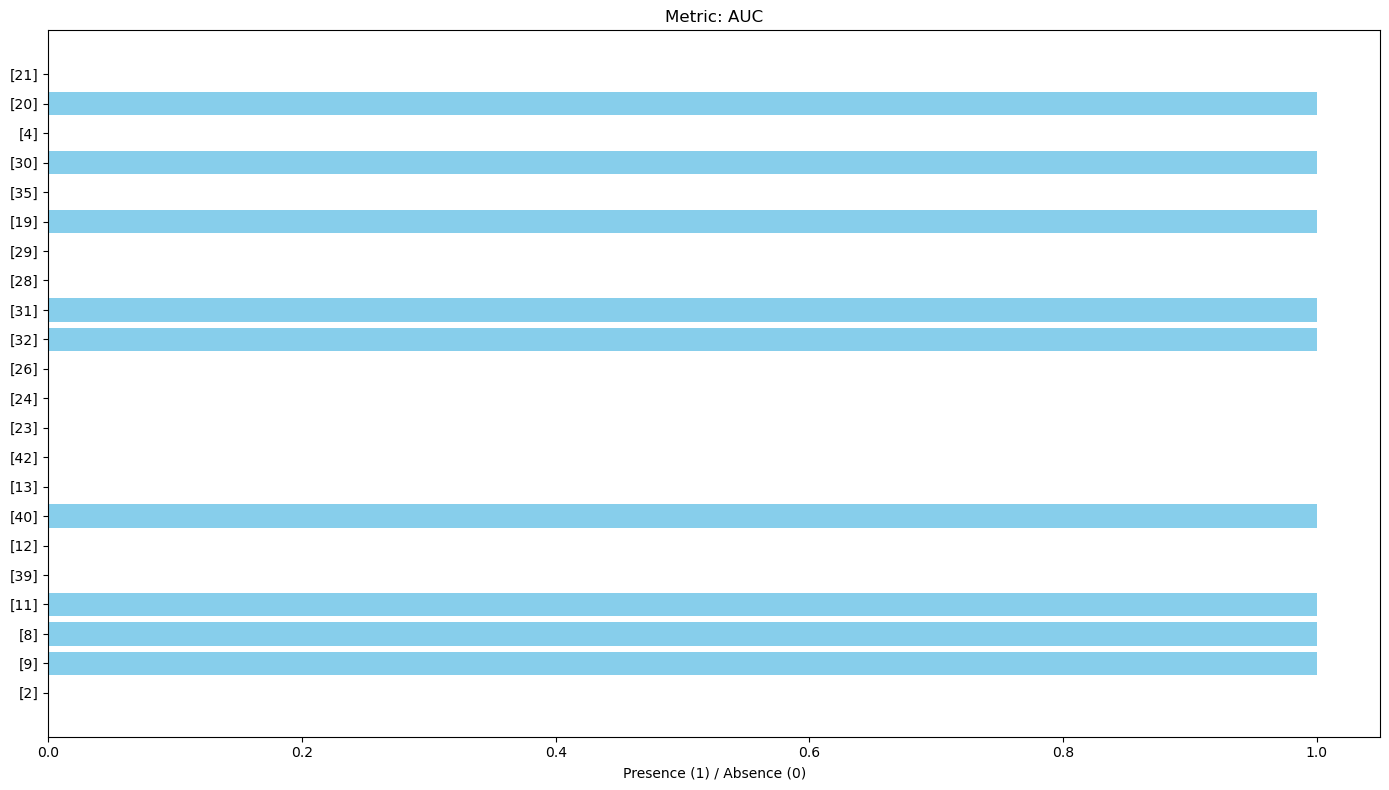

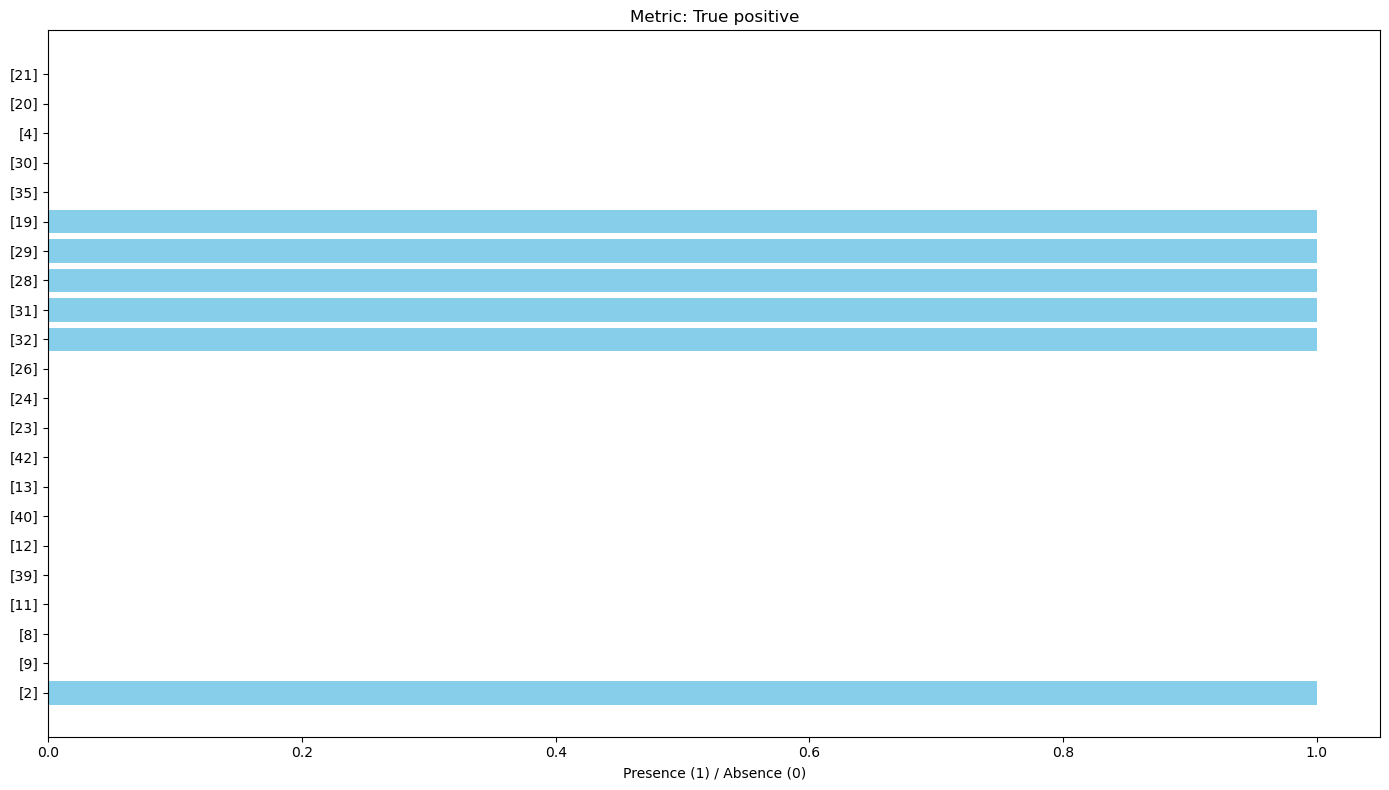

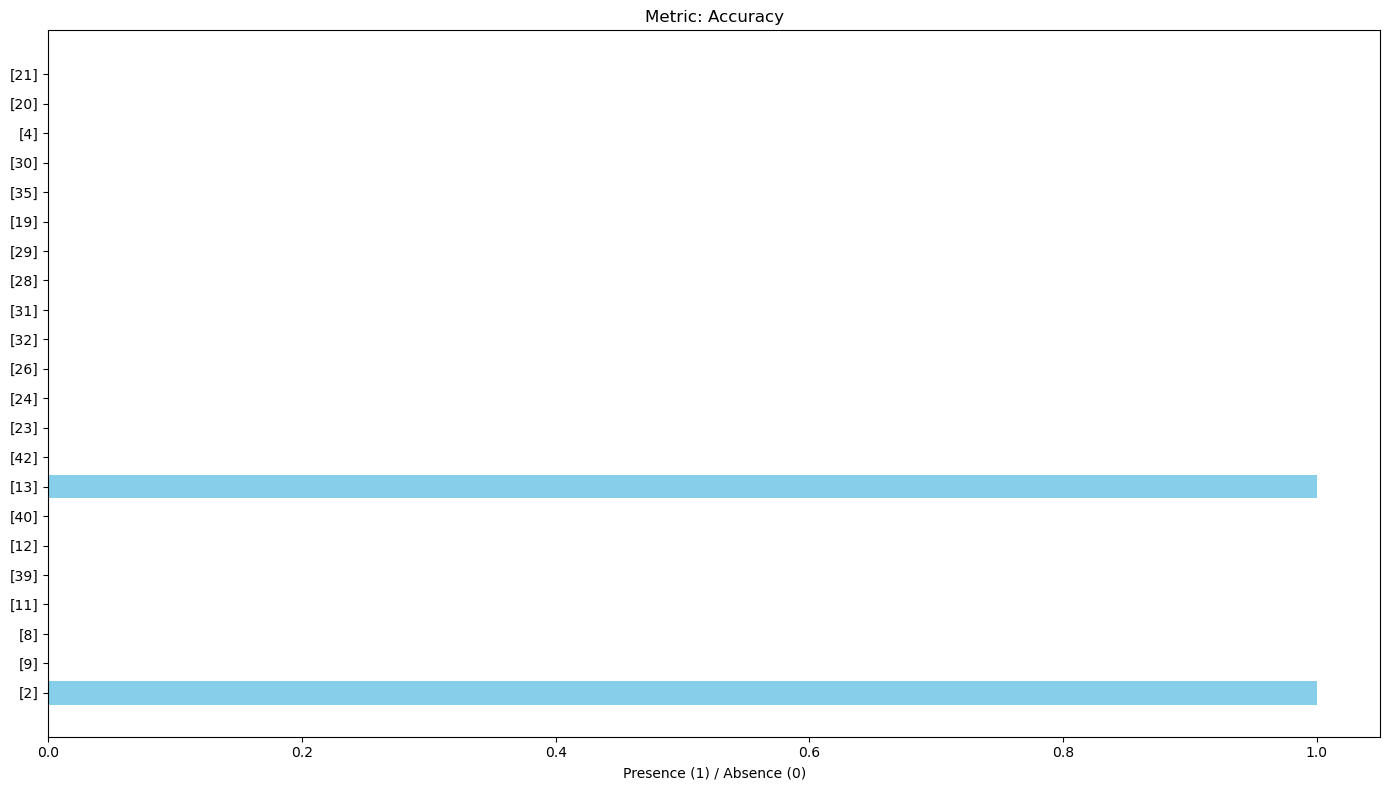

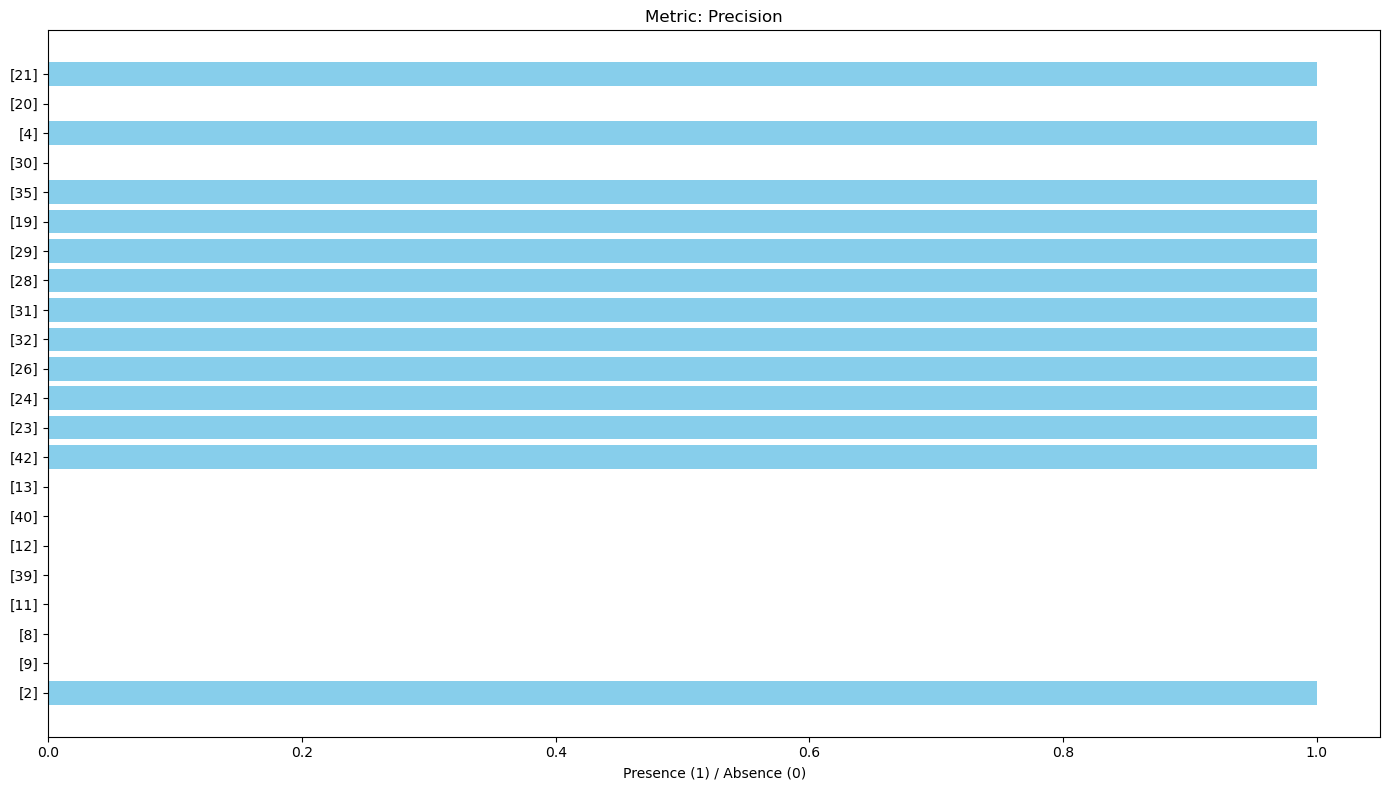

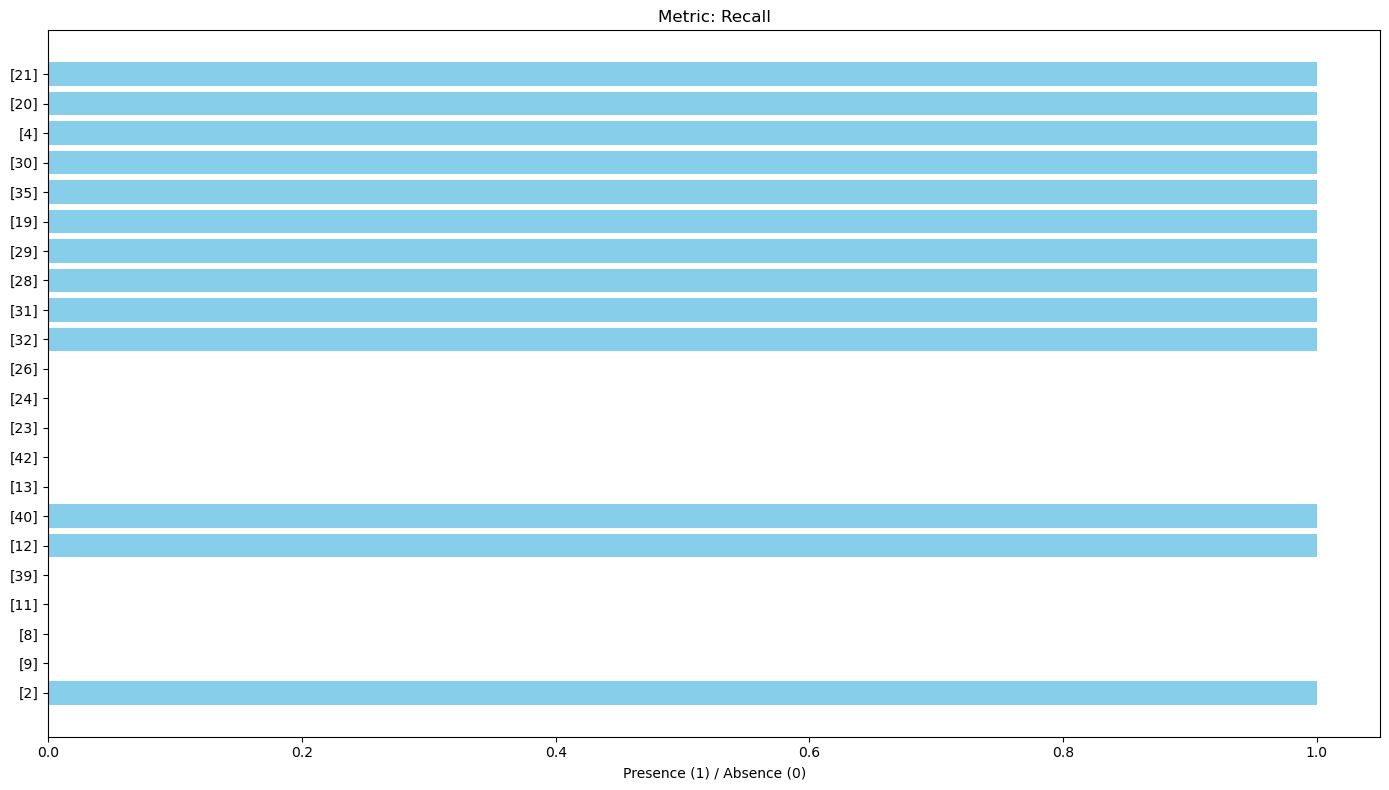

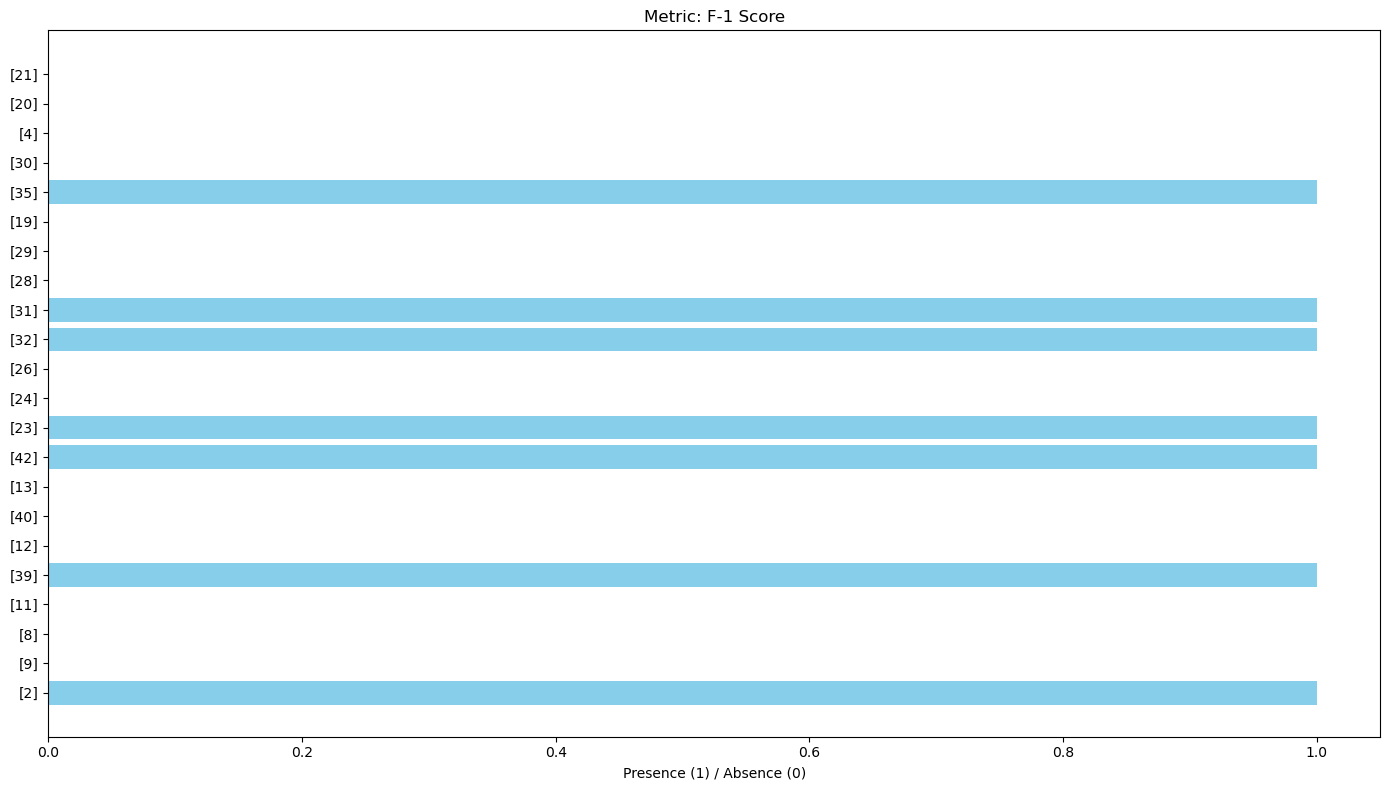

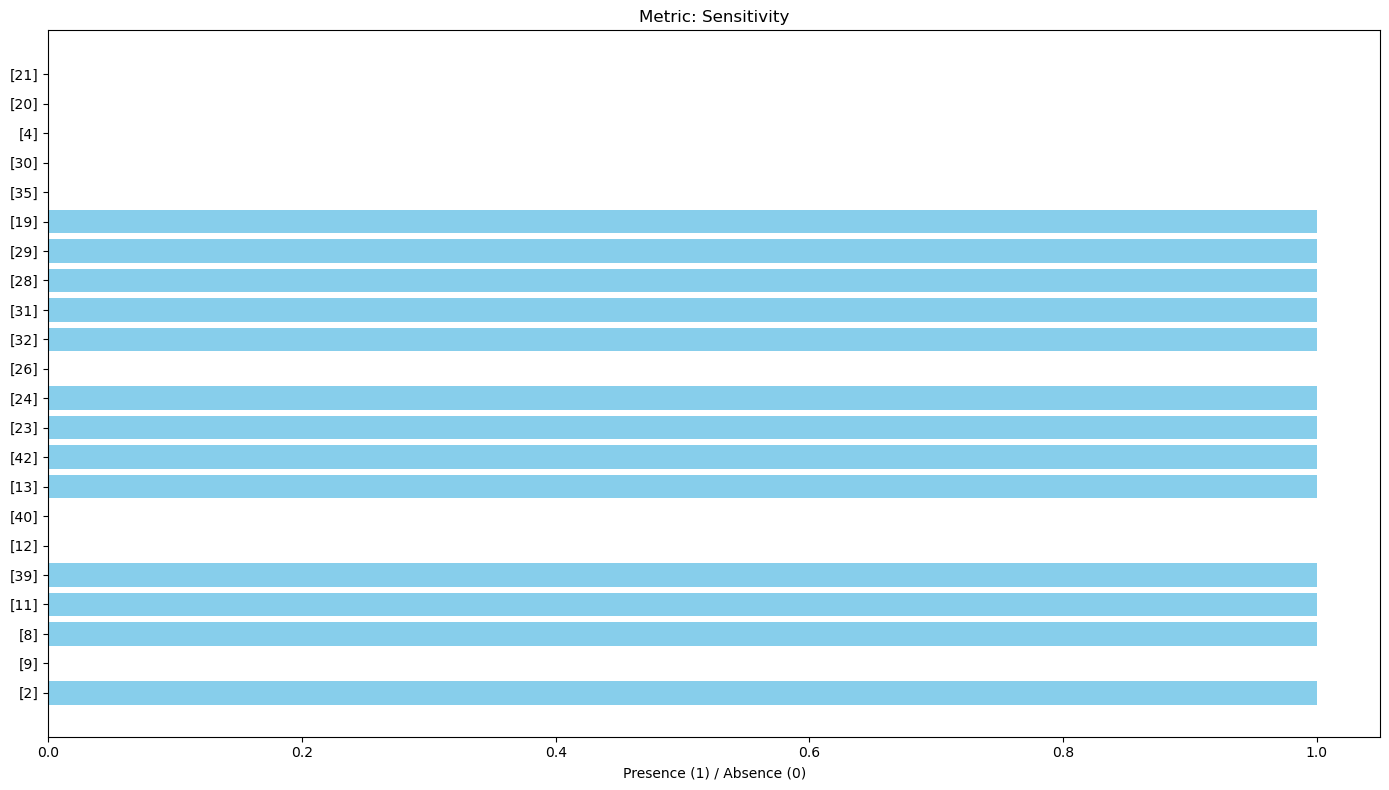

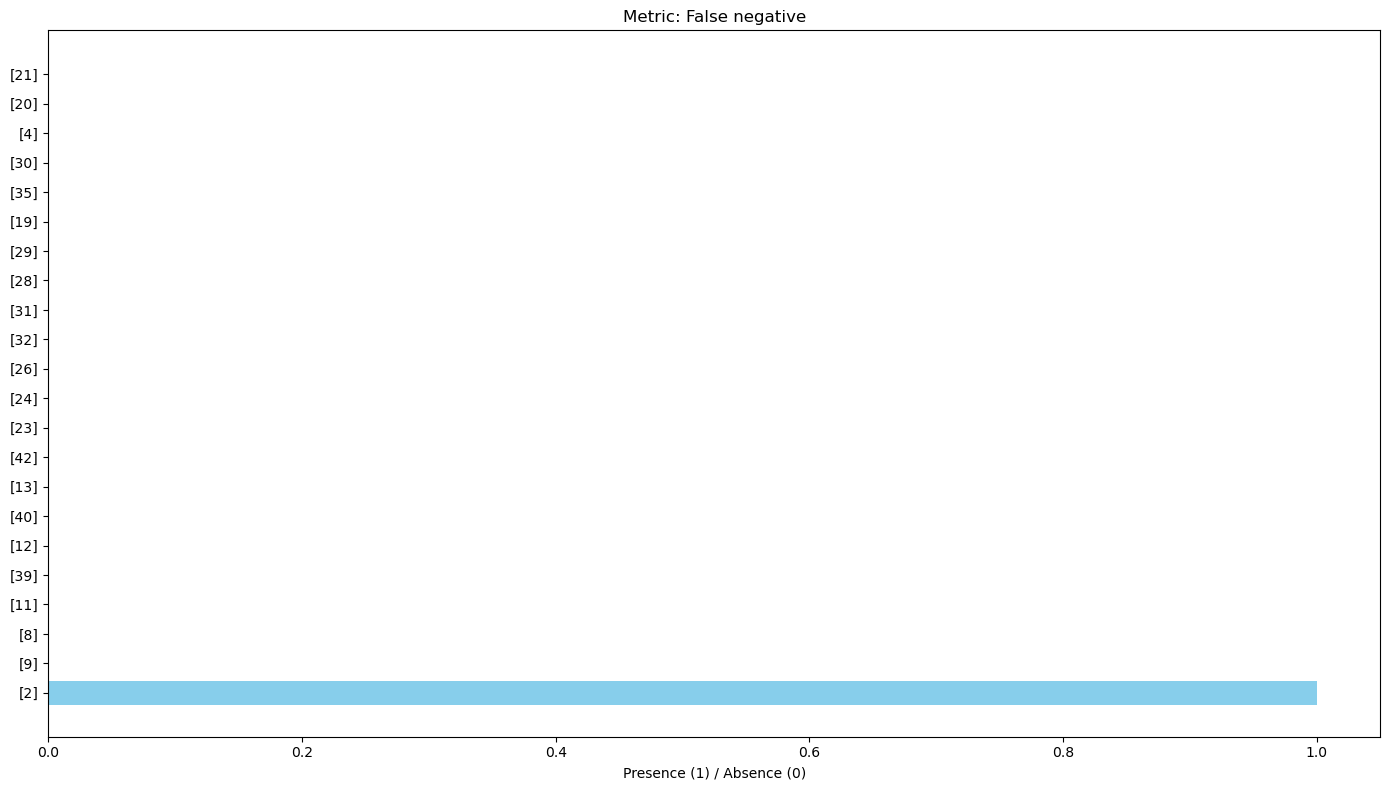

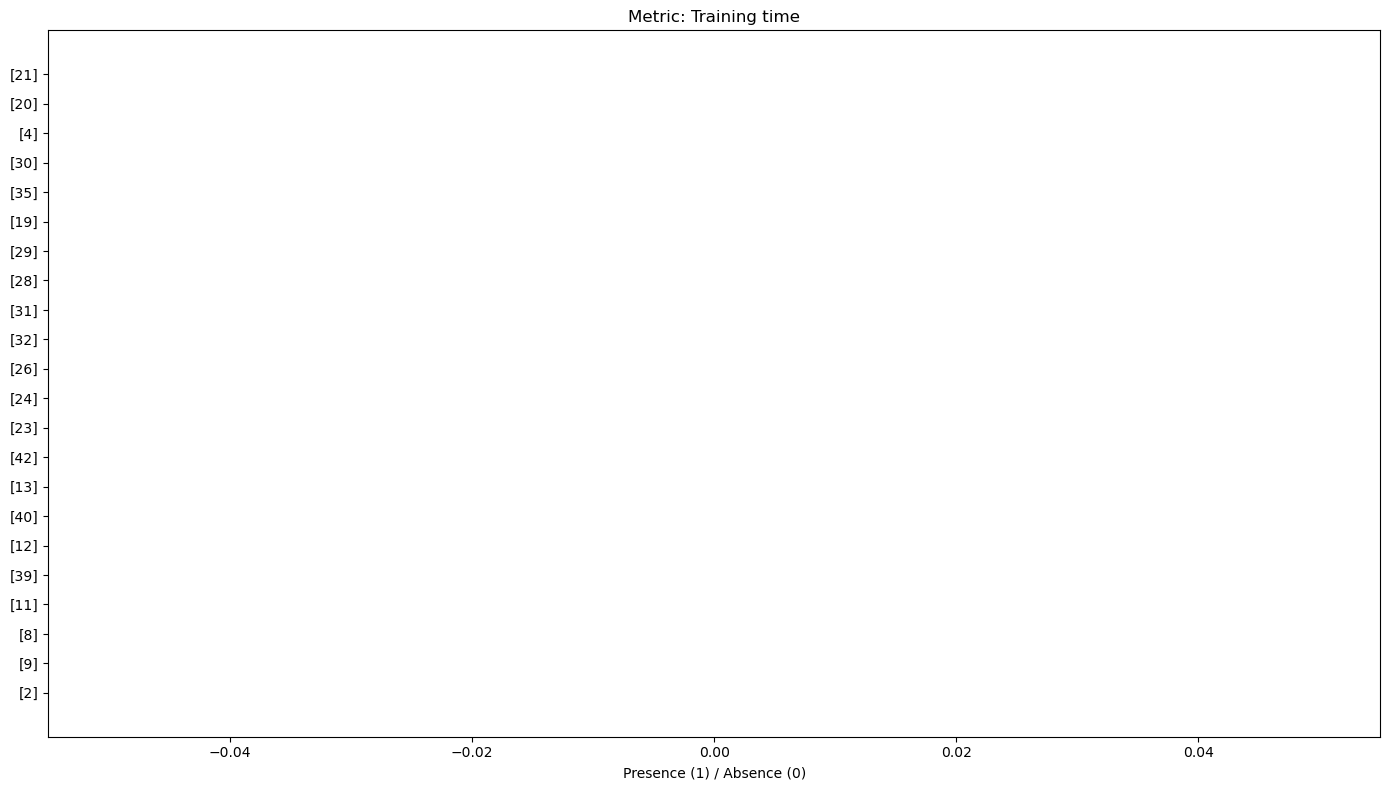

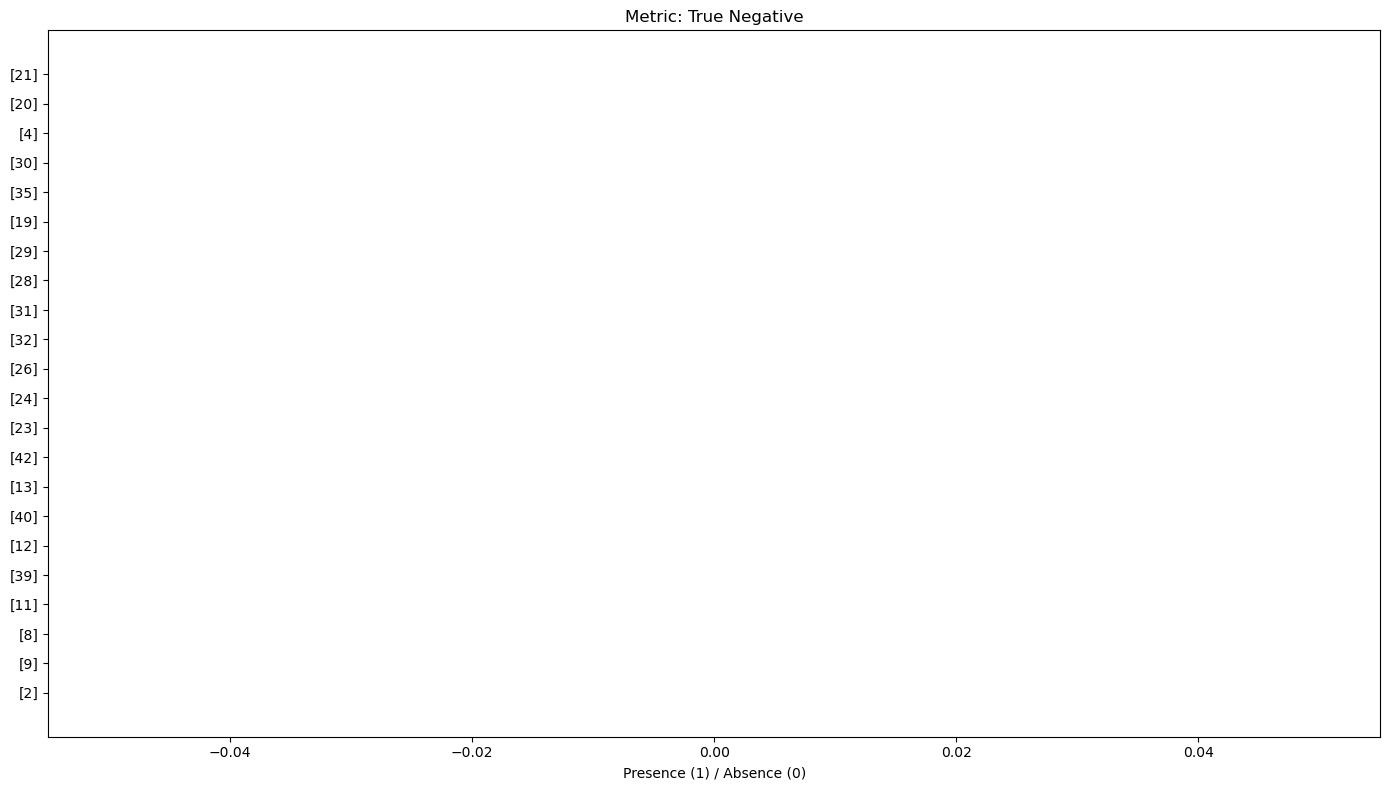

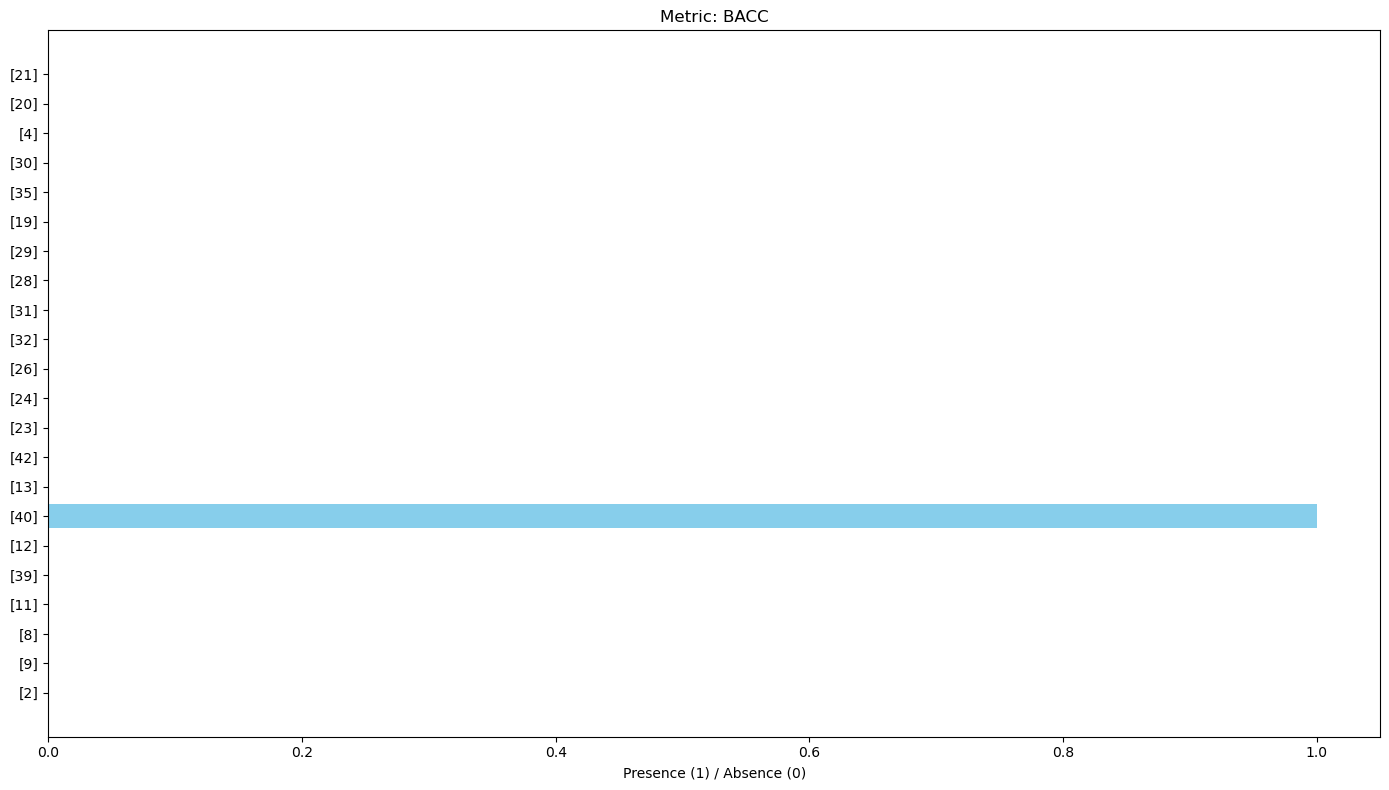

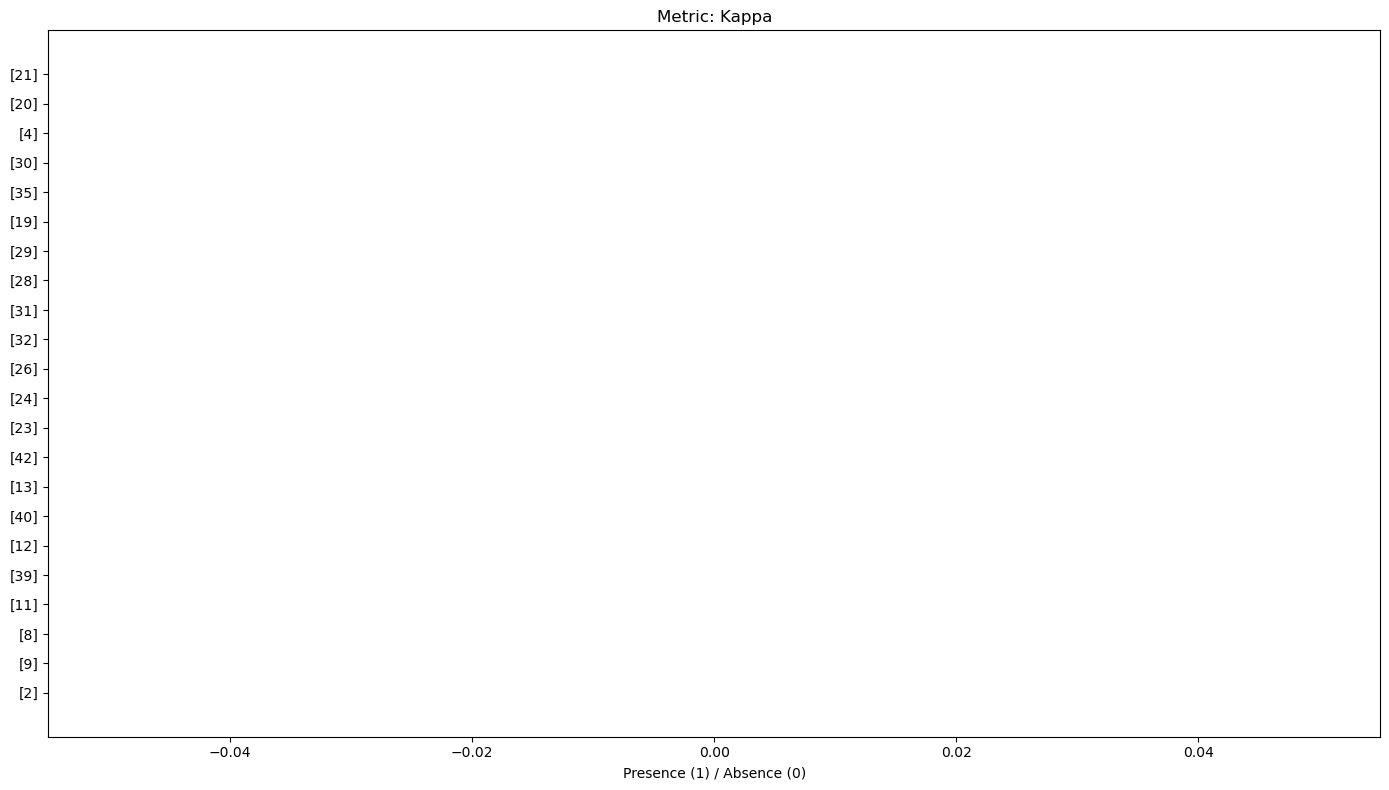

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Authors and metrics
authors = [
    '[2]', '[9]', '[8]', '[11]', '[39]', '[12]', '[40]', '[13]', '[42]', '[23]',
    '[24]', '[26]', '[32]', '[31]', '[28]', '[29]', '[19]', '[35]', '[30]', '[4]',
    '[20]', '[21]'
]
metrics = [
    'False positive', 'AUC', 'True positive', 'Accuracy', 'Precision', 'Recall',
    'F-1 Score', 'Sensitivity', 'False negative', 'Training time', 'True Negative',
    'BACC', 'Kappa'
]

# Data matrix: Rows represent authors, columns represent metrics
data = np.array([
    [1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],  # [2]
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # [9]
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # [8]
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # [11]
    [1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],  # [39]
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # [12]
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],  # [40]
    [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # [13]
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0],  # [42]
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0],  # [23]
    [1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],  # [24]
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # [26]
    [0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # [32]
    [0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # [31]
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # [28]
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # [29]
    [0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # [19]
    [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],  # [35]
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # [30]
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # [4]
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # [20]
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]   # [21]
])

# Plotting each metric as a horizontal bar chart
for i, metric in enumerate(metrics):
    plt.figure(figsize=(14, 8))
    plt.barh(authors, data[:, i], color='skyblue')
    plt.xlabel('Presence (1) / Absence (0)')
    plt.title(f'Metric: {metric}')
    plt.tight_layout()
    plt.show()


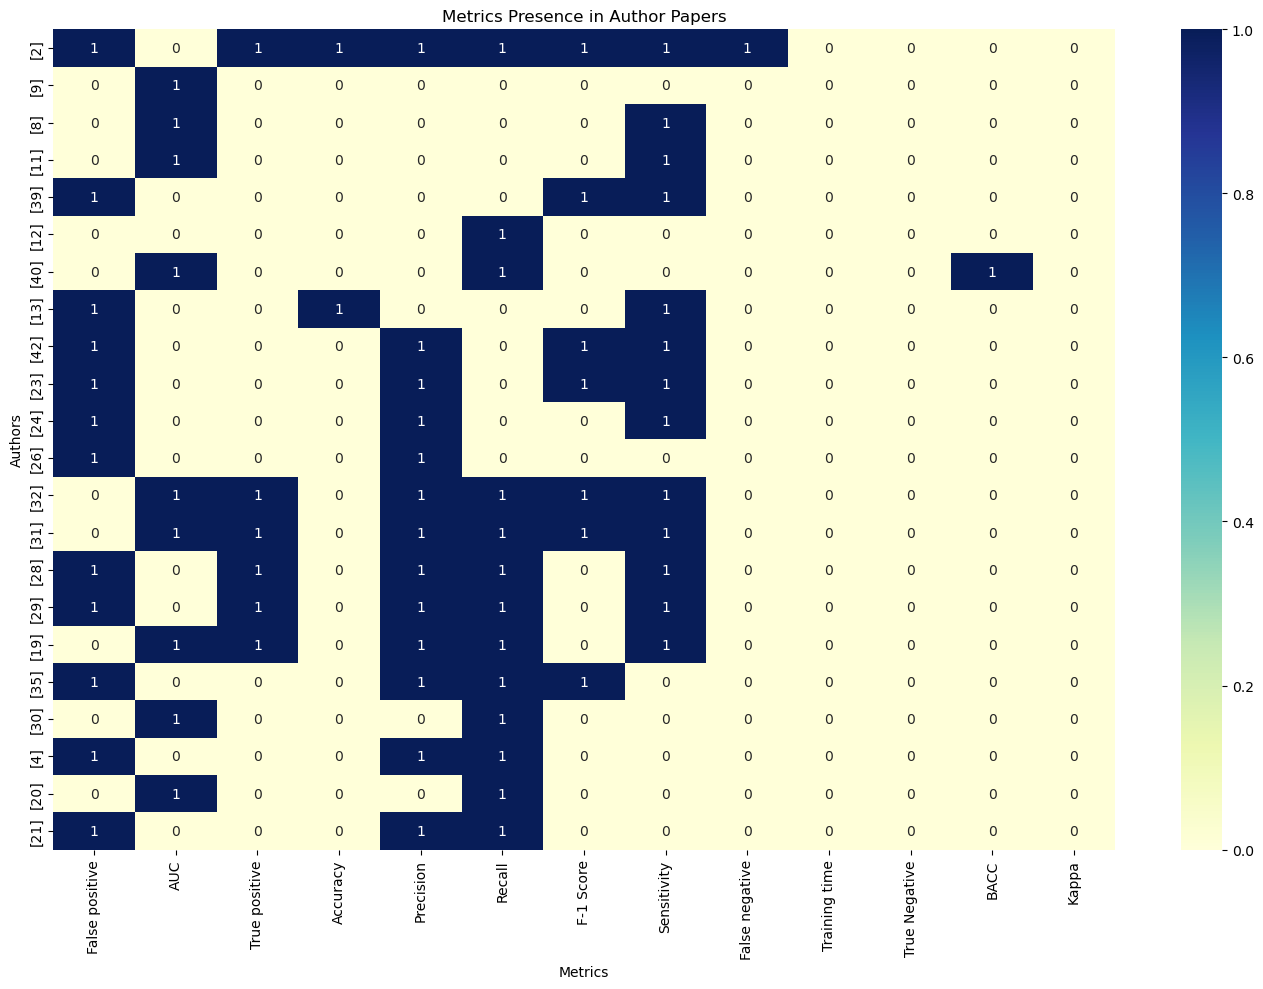

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Authors and metrics
authors = [
    '[2]', '[9]', '[8]', '[11]', '[39]', '[12]', '[40]', '[13]', '[42]', '[23]',
    '[24]', '[26]', '[32]', '[31]', '[28]', '[29]', '[19]', '[35]', '[30]', '[4]',
    '[20]', '[21]'
]
metrics = [
    'False positive', 'AUC', 'True positive', 'Accuracy', 'Precision', 'Recall',
    'F-1 Score', 'Sensitivity', 'False negative', 'Training time', 'True Negative',
    'BACC', 'Kappa'
]

# Data matrix
data = np.array([
    [1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],  # [2]
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # [9]
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # [8]
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # [11]
    [1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],  # [39]
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # [12]
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],  # [40]
    [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # [13]
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0],  # [42]
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0],  # [23]
    [1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],  # [24]
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # [26]
    [0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # [32]
    [0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # [31]
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # [28]
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # [29]
    [0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # [19]
    [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],  # [35]
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # [30]
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # [4]
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # [20]
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]   # [21]
])

# Plotting heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(data, annot=True, fmt='d', cmap='YlGnBu', xticklabels=metrics, yticklabels=authors)
plt.xlabel('Metrics')
plt.ylabel('Authors')
plt.title('Metrics Presence in Author Papers')
plt.tight_layout()
plt.show()


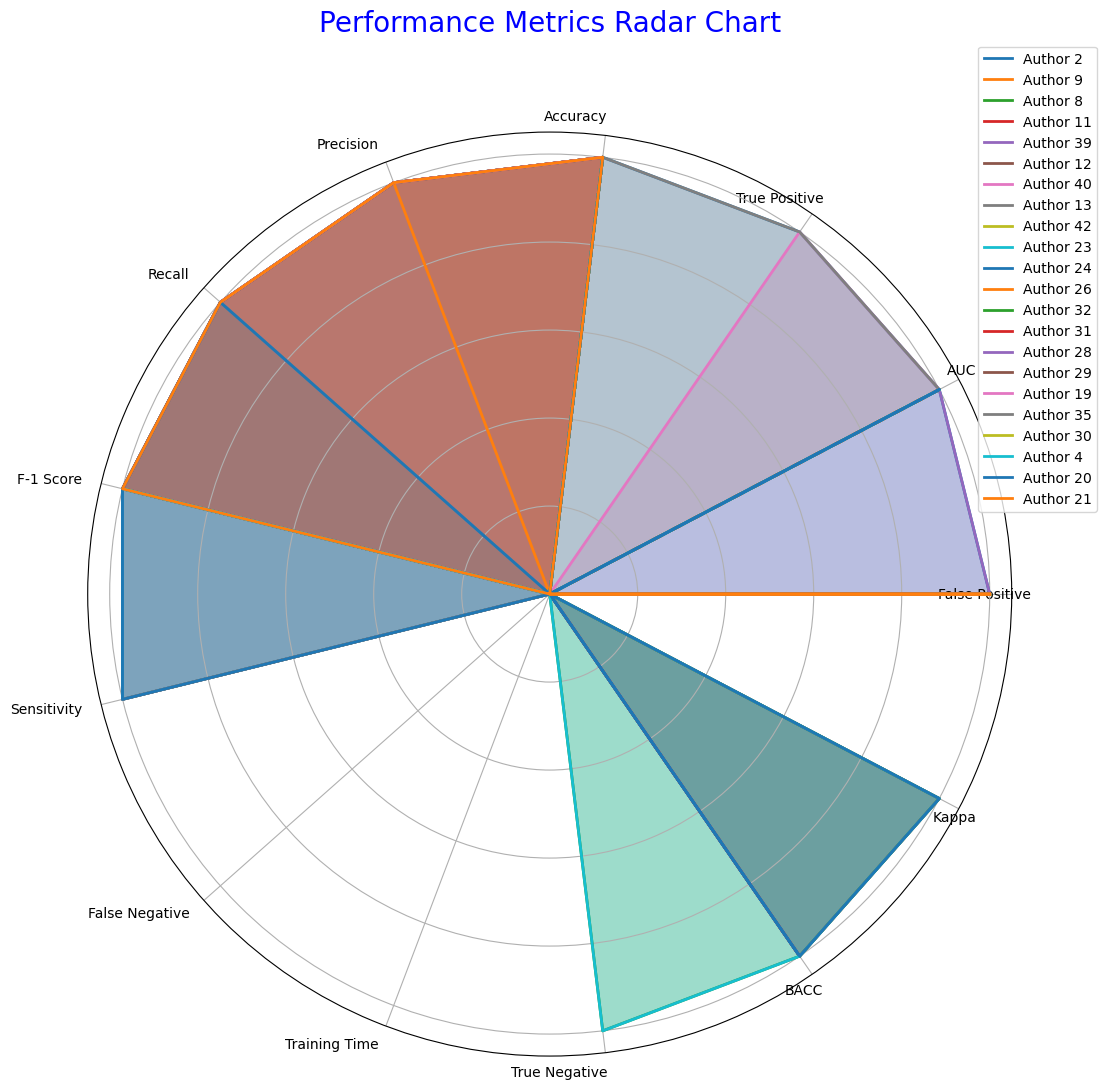

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Define the metrics
metrics = [
    'False Positive', 'AUC', 'True Positive', 'Accuracy', 'Precision', 
    'Recall', 'F-1 Score', 'Sensitivity', 'False Negative', 'Training Time', 
    'True Negative', 'BACC', 'Kappa'
]

# Define the authors and their data
data = {
    '2':  [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],   # [2]
    '9':  [0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0],   # [9]
    '8':  [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],   # [8]
    '11': [0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1],   # [11]
    '39': [1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],   # [39]
    '12': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],   # [12]
    '40': [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],   # [40]
    '13': [0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [13]
    '42': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],   # [42]
    '23': [1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0],   # [23]
    '24': [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0],   # [24]
    '26': [1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],   # [26]
    '32': [0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1],   # [32]
    '31': [0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [31]
    '28': [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [28]
    '29': [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [29]
    '19': [0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [19]
    '35': [1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],   # [35]
    '30': [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],   # [30]
    '4':  [0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1],   # [4]
    '20': [0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1],   # [20]
    '21': [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [21]
}

# Function to create radar chart
def radar_chart(data, title):
    num_vars = len(metrics)
    
    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
    
    for author, values in data.items():
        values += values[:1]  # Complete the loop for each author
        ax.plot(angles, values, label=f'Author {author}', linewidth=2)
        ax.fill(angles, values, alpha=0.25)
    
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.set_title(title, size=20, color='blue', y=1.1)
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()

# Call the function to create and show the radar chart
radar_chart(data, 'Performance Metrics Radar Chart')


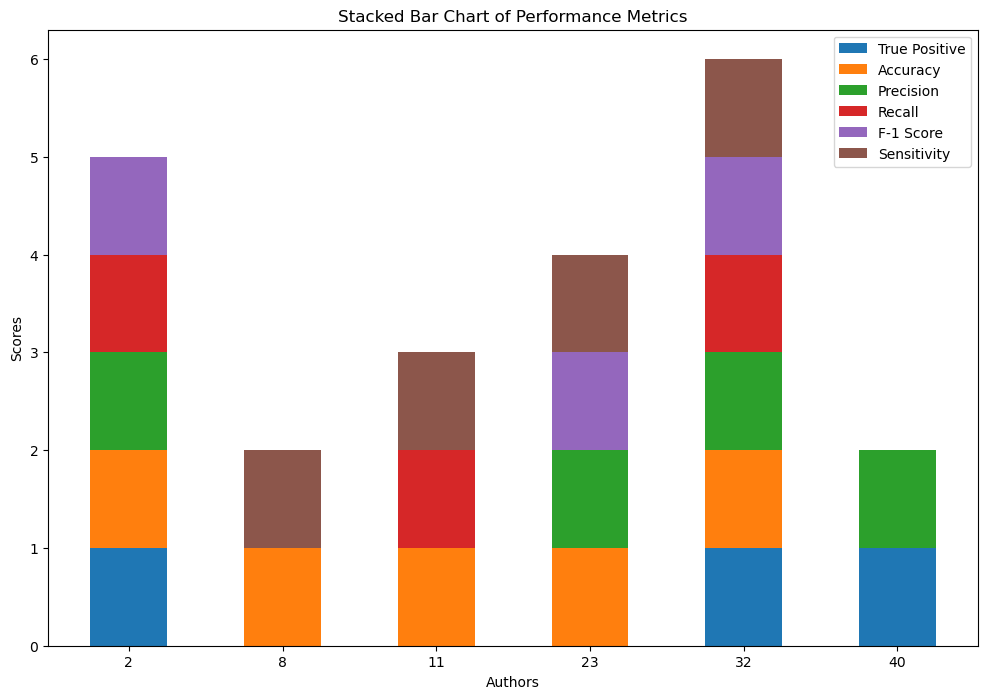

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
authors = ['2', '8', '11', '23', '32', '40']
true_positive = [1, 0, 0, 0, 1, 1]
accuracy = [1, 1, 1, 1, 1, 0]
precision = [1, 0, 0, 1, 1, 1]
recall = [1, 0, 1, 0, 1, 0]
f1_score = [1, 0, 0, 1, 1, 0]
sensitivity = [0, 1, 1, 1, 1, 0]

# Stacked bar chart
bar_width = 0.5
x = np.arange(len(authors))

fig, ax = plt.subplots(figsize=(12, 8))

# Stack bars
ax.bar(x, true_positive, bar_width, label='True Positive')
ax.bar(x, accuracy, bar_width, bottom=true_positive, label='Accuracy')
ax.bar(x, precision, bar_width, bottom=np.array(true_positive) + np.array(accuracy), label='Precision')
ax.bar(x, recall, bar_width, bottom=np.array(true_positive) + np.array(accuracy) + np.array(precision), label='Recall')
ax.bar(x, f1_score, bar_width, bottom=np.array(true_positive) + np.array(accuracy) + np.array(precision) + np.array(recall), label='F-1 Score')
ax.bar(x, sensitivity, bar_width, bottom=np.array(true_positive) + np.array(accuracy) + np.array(precision) + np.array(recall) + np.array(f1_score), label='Sensitivity')

ax.set_xlabel('Authors')
ax.set_ylabel('Scores')
ax.set_title('Stacked Bar Chart of Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(authors)
ax.legend()

plt.show()


C:\Users\NK\AppData\Local\Temp\ipykernel_9616\1473862649.py:54: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(metrics, rotation=45, ha='right')


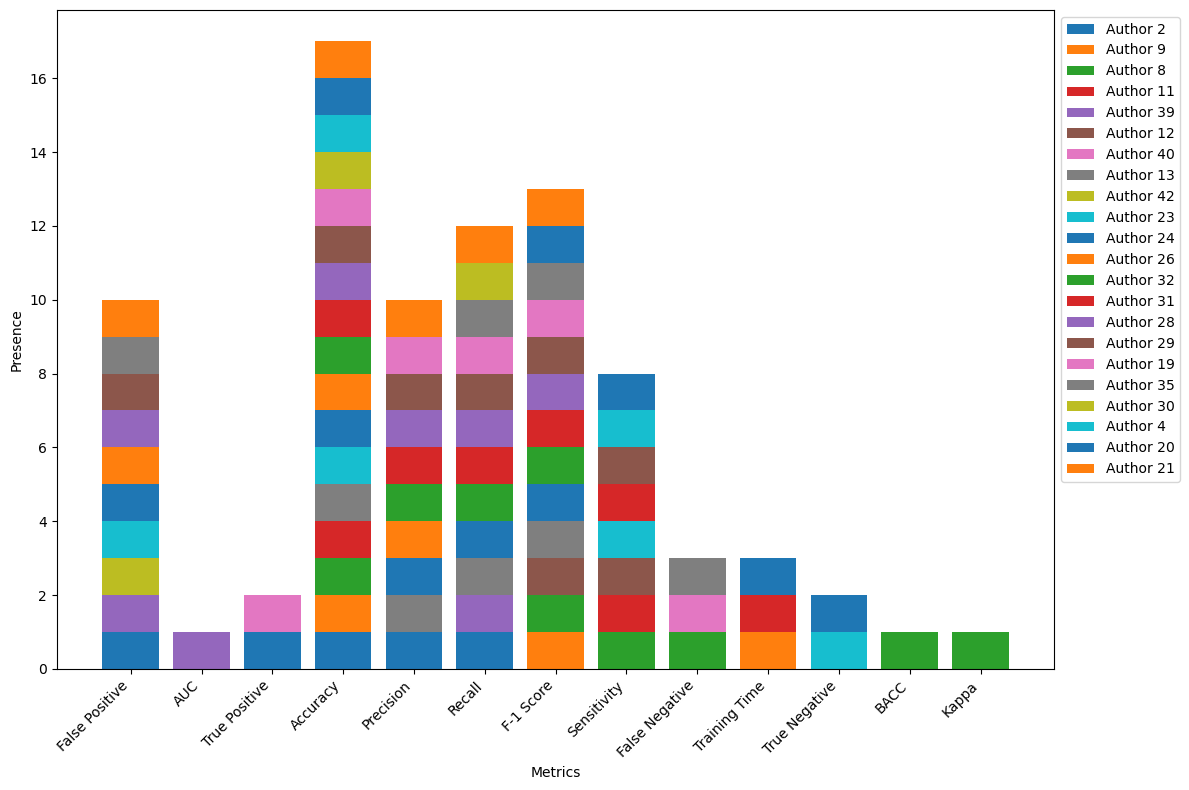

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Define the metrics
metrics = [
    'False Positive', 'AUC', 'True Positive', 'Accuracy', 'Precision', 
    'Recall', 'F-1 Score', 'Sensitivity', 'False Negative', 'Training Time', 
    'True Negative', 'BACC', 'Kappa'
]

# Define the authors and their data
data = {
    '2':  [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],   # [2]
    '9':  [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0],   # [9]
    '8':  [0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0],   # [8]
    '11': [0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0],   # [11]
    '39': [1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],   # [39]
    '12': [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],   # [12]
    '40': [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],   # [40]
    '13': [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [13]
    '42': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],   # [42]
    '23': [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],   # [23]
    '24': [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [24]
    '26': [1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],   # [26]
    '32': [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1],   # [32]
    '31': [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],   # [31]
    '28': [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [28]
    '29': [1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],   # [29]
    '19': [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [19]
    '35': [1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0],   # [35]
    '30': [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],   # [30]
    '4':  [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0],   # [4]
    '20': [0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0],   # [20]
    '21': [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],   # [21]
}

# Convert the data into a format suitable for a stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Create an array of zeros with the shape (number of metrics, number of authors)
bottoms = np.zeros(len(metrics))

# Plot each author's data
for author, values in data.items():
    values = np.array(values)
    ax.bar(metrics, values, label=f'Author {author}', bottom=bottoms)
    bottoms += values

# Customize the plot
ax.set_xlabel('Metrics')
ax.set_ylabel('Presence')
#ax.set_title('Stacked Bar Chart of Performance Metrics')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_xticklabels(metrics, rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [7]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph()

# Global graph attributes
dot.attr(dpi='100', rankdir='TB', size='10,8', bgcolor='#f5f5f5')

# Define node styles
dot.attr('node', shape='box', style='rounded,filled', fontname='Helvetica', fontsize='12', color='black', fillcolor='#e0f7fa', fontcolor='black')

# Add nodes with custom attributes
dot.node('A', 'Systematic Literature Review', fillcolor='#b2ebf2')
dot.node('B', 'Dataset Selection', fillcolor='#80deea')
dot.node('C', 'Data Preprocessing', fillcolor='#4fc3f7')
dot.node('D', 'Models Selection', fillcolor='#29b6f6')
dot.node('E', 'Training Models', fillcolor='#03a9f4')
dot.node('F', 'Evaluating Models', fillcolor='#0288d1')
dot.node('G', 'Real Time Testing', fillcolor='#0277bd')
dot.node('H', 'Comparing Models', fillcolor='#01579b')

# Define edge styles
dot.attr('edge', color='black', fontsize='10', fontname='Helvetica')

# Add edges with custom attributes
dot.edge('A', 'B', color='#00796b')
dot.edge('B', 'C', color='#00796b')
dot.edge('C', 'D', color='#00796b')
dot.edge('D', 'E', color='#00796b')
dot.edge('E', 'F', color='#00796b')
dot.edge('F', 'G', color='#00796b')
dot.edge('G', 'H', color='#00796b')

# Render the graph to a file and display it
dot.render('methodology_pipeline', format='png', cleanup=True)
dot.view('methodology_pipeline')


'methodology_pipeline.pdf'

In [11]:
from kafka import KafkaConsumer
import json

# Create a Kafka consumer
consumer = KafkaConsumer(
    'network-traffic',
    bootstrap_servers='localhost:9092',
    auto_offset_reset='earliest',
    enable_auto_commit=True,
    group_id='my-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

for message in consumer:
    traffic_data = message.value
    # Preprocess the traffic data as required by your model


NoBrokersAvailable: NoBrokersAvailable

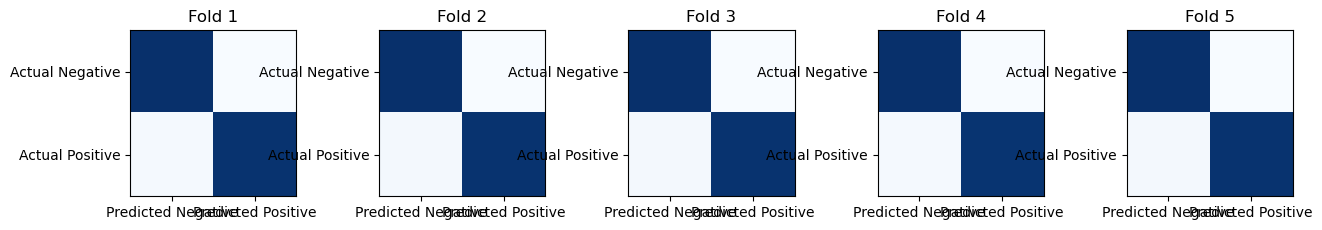

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have the confusion matrices for each fold
cm_fold1 = np.array([[230904, 1637], [4868, 227325]])
cm_fold2 = np.array([[230844, 1332], [5004, 227554]])
cm_fold3 = np.array([[230840, 1332], [5011, 227531]])
cm_fold4 = np.array([[231197, 1440], [4822, 227275]])
cm_fold5 = np.array([[230987, 1302], [4920, 227525]])

# Create a figure with 5 subplots
fig, ax = plt.subplots(1, 5, figsize=(15, 3))

# Plot each confusion matrix in a subplot
ax[0].imshow(cm_fold1, cmap='Blues')
ax[0].set_title('Fold 1')
ax[1].imshow(cm_fold2, cmap='Blues')
ax[1].set_title('Fold 2')
ax[2].imshow(cm_fold3, cmap='Blues')
ax[2].set_title('Fold 3')
ax[3].imshow(cm_fold4, cmap='Blues')
ax[3].set_title('Fold 4')
ax[4].imshow(cm_fold5, cmap='Blues')
ax[4].set_title('Fold 5')

# Set labels and tick marks
for i in range(5):
    ax[i].set_xticks([0, 1])
    ax[i].set_yticks([0, 1])
    ax[i].set_xticklabels(['Predicted Negative', 'Predicted Positive'])
    ax[i].set_yticklabels(['Actual Negative', 'Actual Positive'])

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.5)

# Show the plot
plt.show()





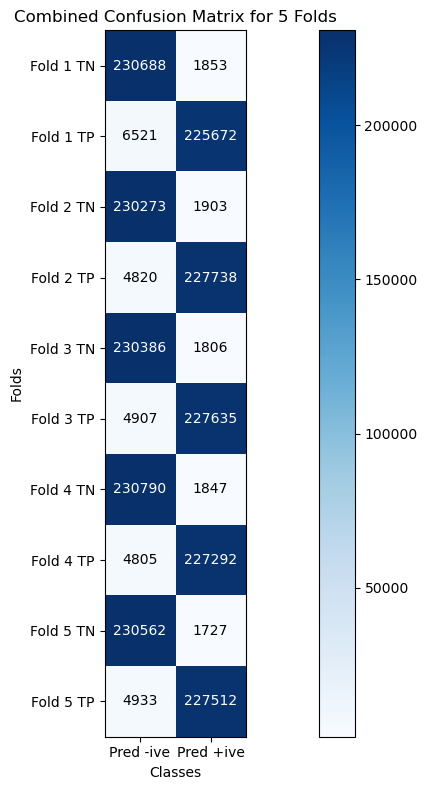

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Example values for each fold (replace these with your actual values)
# For fold 1
tn1, fp1, fn1, tp1 = 230688, 1853, 6521, 225672  # Replace with your actual values
cm_fold1 = np.array([[tn1, fp1], [fn1, tp1]])

# For fold 2
tn2, fp2, fn2, tp2 = 230273, 1903, 4820, 227738  # Replace with your actual values
cm_fold2 = np.array([[tn2, fp2], [fn2, tp2]])

# For fold 3
tn3, fp3, fn3, tp3 = 230386, 1806, 4907, 227635  # Replace with your actual values
cm_fold3 = np.array([[tn3, fp3], [fn3, tp3]])

# For fold 4
tn4, fp4, fn4, tp4 = 230790, 1847, 4805, 227292  # Replace with your actual values
cm_fold4 = np.array([[tn4, fp4], [fn4, tp4]])

# For fold 5
tn5, fp5, fn5, tp5 = 230562, 1727, 4933, 227512  # Replace with your actual values
cm_fold5 = np.array([[tn5, fp5], [fn5, tp5]])

# Combine confusion matrices into a larger matrix
combined_cm = np.zeros((10, 2))  # 5 folds, each with 2 classes (2x5)

# Fill the combined confusion matrix
combined_cm[0:2, 0:2] = cm_fold1
combined_cm[2:4, 0:2] = cm_fold2
combined_cm[4:6, 0:2] = cm_fold3
combined_cm[6:8, 0:2] = cm_fold4
combined_cm[8:10, 0:2] = cm_fold5

# Create a large figure with increased width
plt.figure(figsize=(15, 8))  # Increase the width to 15

# Plot the combined confusion matrix
im = plt.imshow(combined_cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Combined Confusion Matrix for 5 Folds')
plt.colorbar(im)

# Set ticks and labels
plt.xticks([0, 1], ['Pred -ive', 'Pred +ive'])
plt.yticks(np.arange(0, 10, 1), 
           ['Fold 1 TN', 'Fold 1 TP', 
            'Fold 2 TN', 'Fold 2 TP', 
            'Fold 3 TN', 'Fold 3 TP', 
            'Fold 4 TN', 'Fold 4 TP', 
            'Fold 5 TN', 'Fold 5 TP'])

# Annotate the combined confusion matrix
thresh = combined_cm.max() / 2.
for i in range(combined_cm.shape[0]):
    for j in range(combined_cm.shape[1]):
        plt.text(j, i, format(int(combined_cm[i, j]), 'd'),
                 ha="center", va="center",
                 color="white" if combined_cm[i, j] > thresh else "black")

plt.ylabel('Folds')
plt.xlabel('Classes')
plt.tight_layout()
plt.show()


In [2]:
import numpy as np
import pandas as pd
from scipy import stats

# Define the data
data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F-1 Score', 'Specificity', 'ROC-AUC', 'False Positive Rate', 'Time'],
    'CNN-LSTM': [98.00, 99.38, 97.88, 98.63, 99.34, 99.57, 0.6156, 356],
    'CNN-BiLSTM': [98.26, 99.34, 97.84, 98.39, 99.35, 99.60, 0.65, 451],
    'Neuro-symbolic AI': [98.14, 99.20, 97.76, 98.48, 99.21, 99.56, 0.79, 143]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Initialize a list to store results
results = []

# Perform ANOVA for each metric
for index, row in df.iterrows():
    metric = row['Metric']
    # Extract values for each technique for the current metric
    cnn_lstm_values = [row['CNN-LSTM']]
    cnn_bilstm_values = [row['CNN-BiLSTM']]
    neuro_symbolic_ai_values = [row['Neuro-symbolic AI']]
    
    # Perform ANOVA
    f_stat, p_value = stats.f_oneway(cnn_lstm_values, cnn_bilstm_values, neuro_symbolic_ai_values)
    
    # Append results to the list
    results.append({
        'Metric': metric,
        'F-Statistic': f_stat,
        'P-Value': p_value
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the results
print("ANOVA Results:\n")
print(results_df)

# Optionally, save to CSV
results_df.to_csv('anova_results.csv', index=False)


C:\Users\NK\anaconda3_11\Lib\site-packages\scipy\stats\_stats_py.py:4141: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  warnings.warn(stats.DegenerateDataWarning(msg))


ANOVA Results:

                Metric  F-Statistic  P-Value
0             Accuracy          NaN      NaN
1            Precision          NaN      NaN
2               Recall          NaN      NaN
3            F-1 Score          NaN      NaN
4          Specificity          NaN      NaN
5              ROC-AUC          NaN      NaN
6  False Positive Rate          NaN      NaN
7                 Time          NaN      NaN


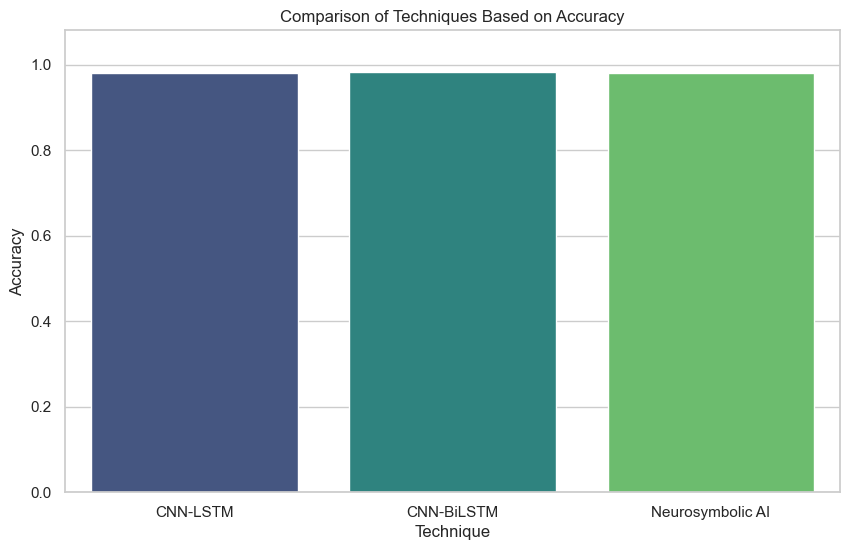

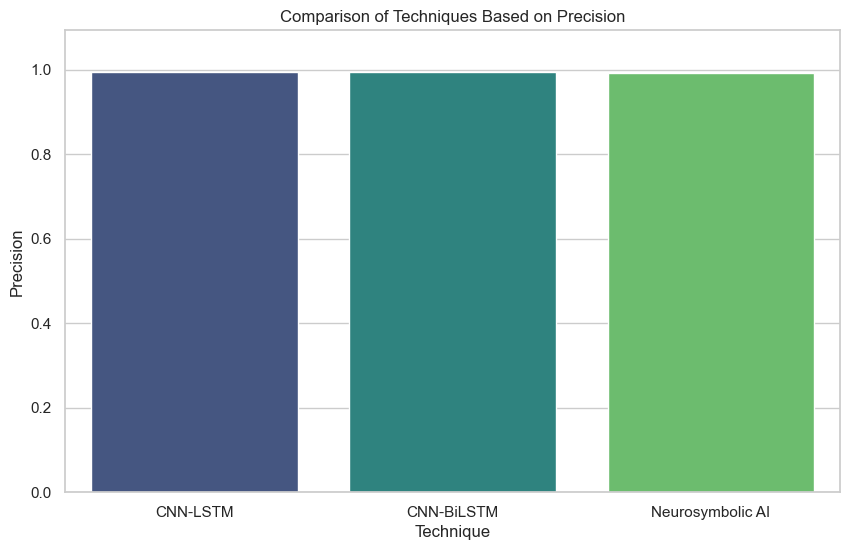

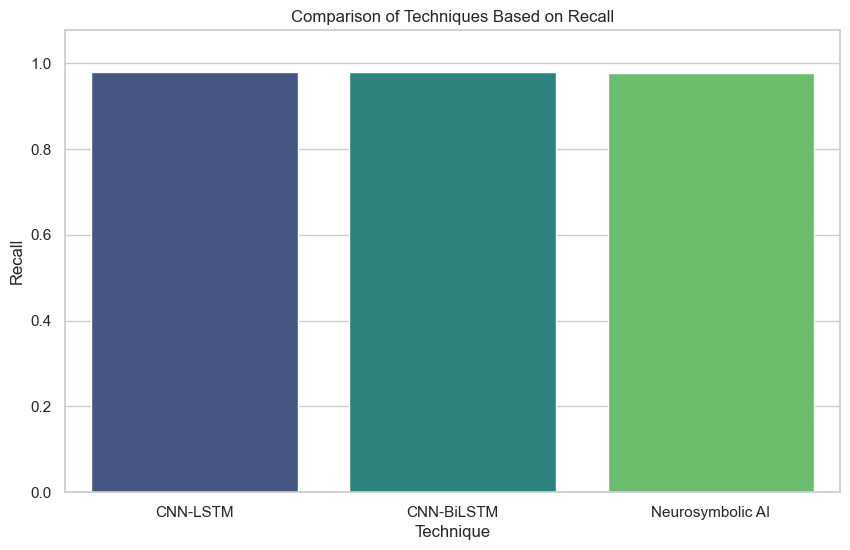

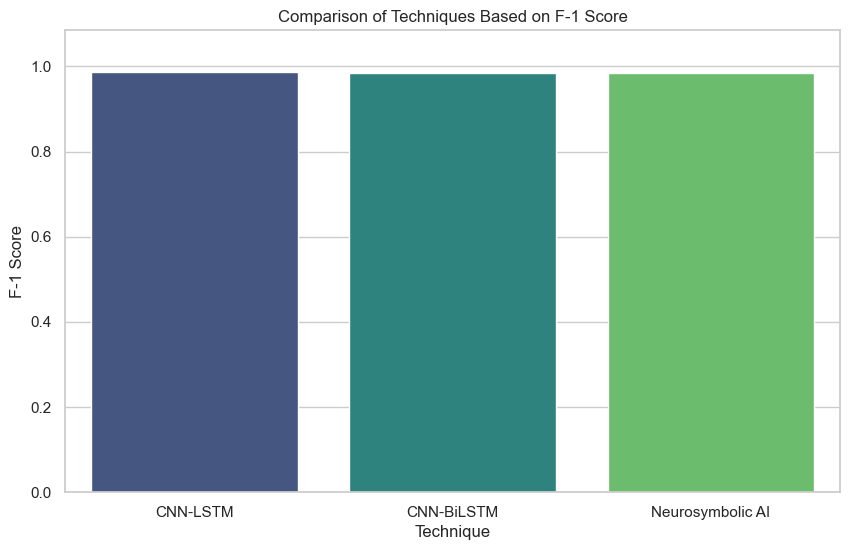

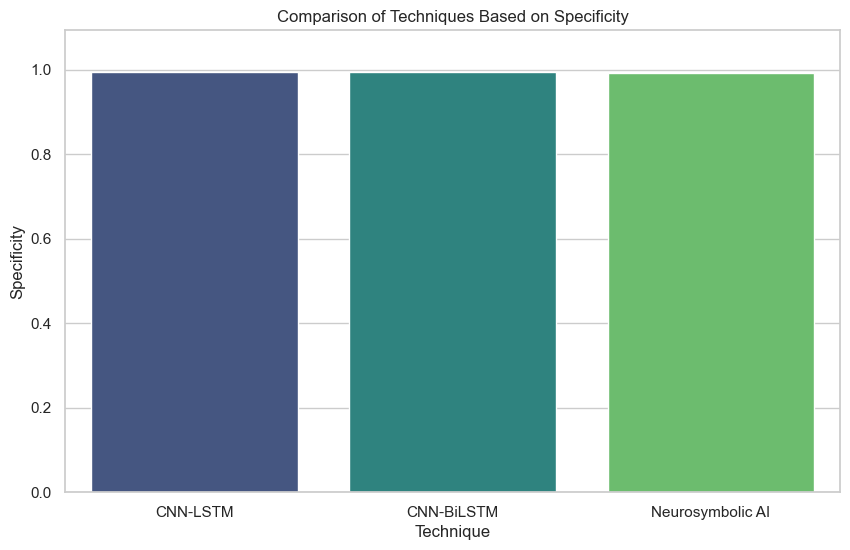

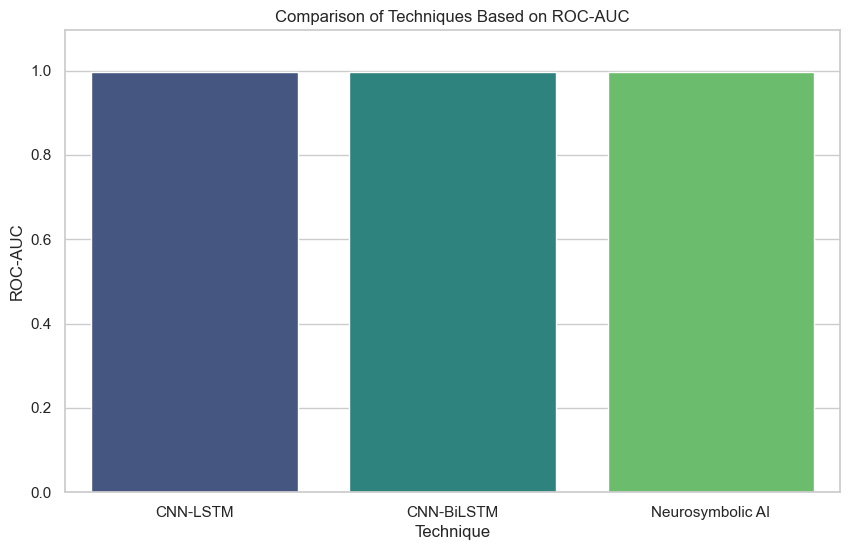

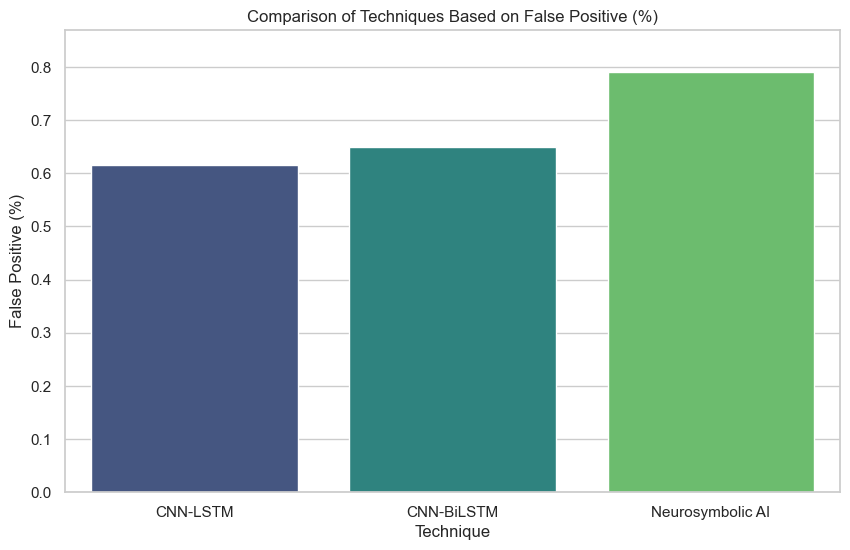

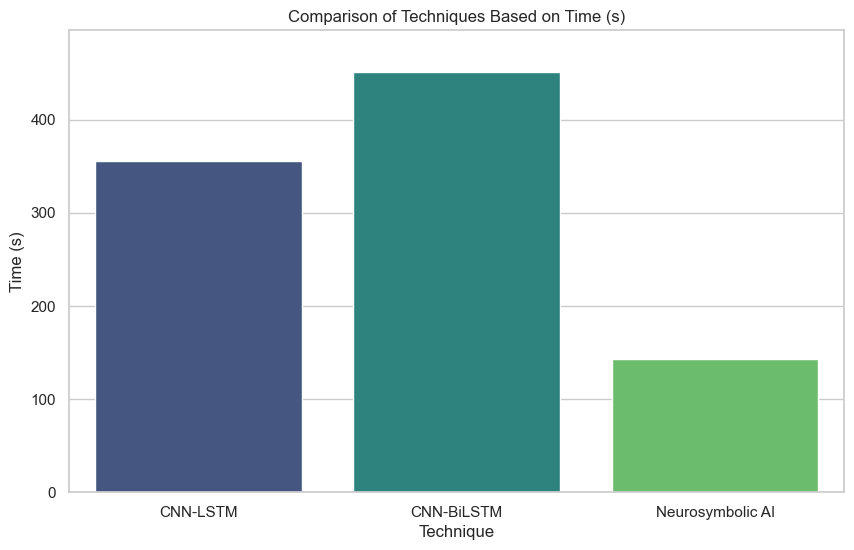

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = {
    'Technique': ['CNN-LSTM', 'CNN-BiLSTM', 'Neurosymbolic AI'],
    'Accuracy': [0.9800, 0.9826, 0.9814],
    'Precision': [0.9938, 0.9934, 0.9920],
    'Recall': [0.9788, 0.9784, 0.9776],
    'F-1 Score': [0.9863, 0.9839, 0.9848],
    'Specificity': [0.9934, 0.9935, 0.9921],
    'ROC-AUC': [0.9957, 0.9960, 0.9956],
    'False Positive (%)': [0.6156, 0.65, 0.79],
    'Time (s)': [356, 451, 143]
}

df = pd.DataFrame(data)

# Set the style of seaborn
sns.set(style="whitegrid")

# Plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F-1 Score', 'Specificity', 'ROC-AUC', 'False Positive (%)', 'Time (s)']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Technique', y=metric, data=df, palette='viridis')
    plt.title(f'Comparison of Techniques Based on {metric}')
    plt.xlabel('Technique')
    plt.ylabel(metric)
    plt.ylim(0, max(df[metric]) * 1.1)  # Adjust y-axis limit for better visualization
    plt.show()


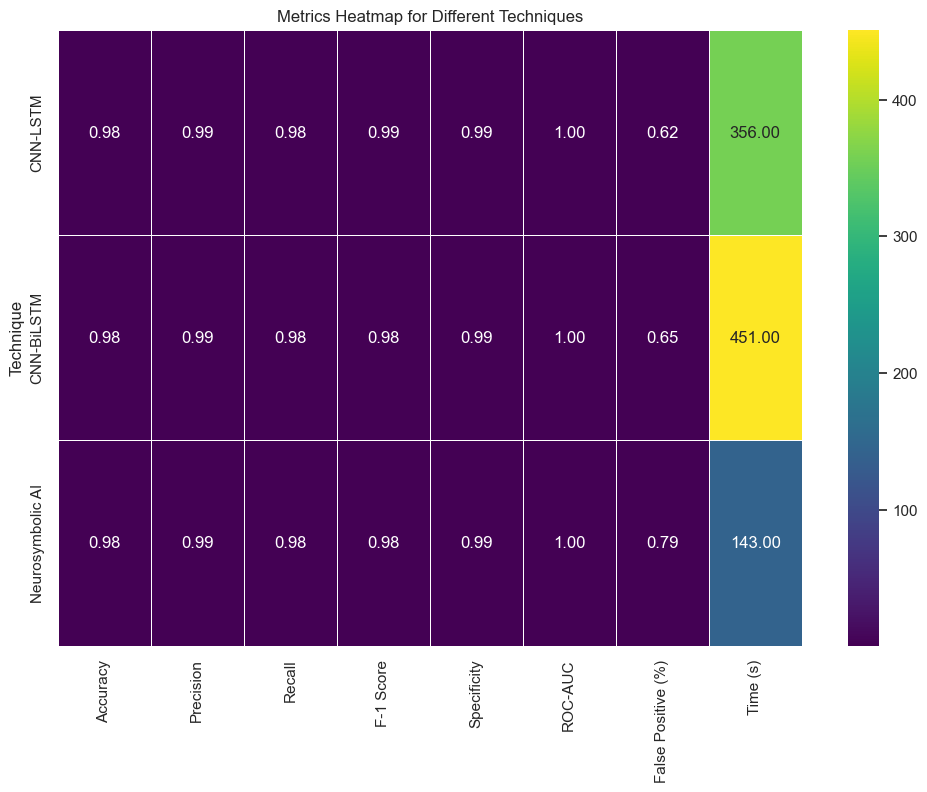

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data
data = {
    'Technique': ['CNN-LSTM', 'CNN-BiLSTM', 'Neurosymbolic AI'],
    'Accuracy': [0.9800, 0.9826, 0.9814],
    'Precision': [0.9938, 0.9934, 0.9920],
    'Recall': [0.9788, 0.9784, 0.9776],
    'F-1 Score': [0.9863, 0.9839, 0.9848],
    'Specificity': [0.9934, 0.9935, 0.9921],
    'ROC-AUC': [0.9957, 0.9960, 0.9956],
    'False Positive (%)': [0.6156, 0.65, 0.79],
    'Time (s)': [356, 451, 143]
}

# Create DataFrame
df = pd.DataFrame(data).set_index('Technique')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Metrics Heatmap for Different Techniques')
plt.show()


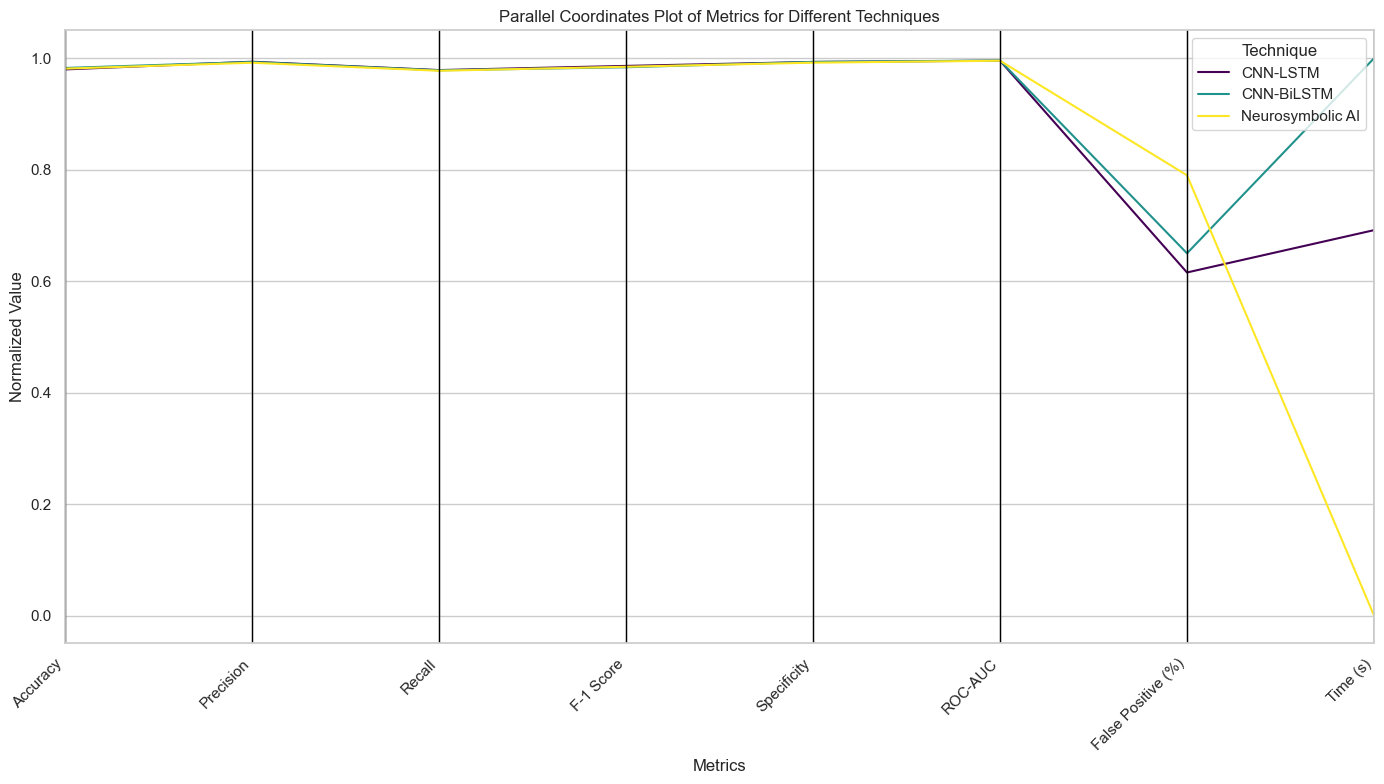

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates

# Data
data = {
    'Technique': ['CNN-LSTM', 'CNN-BiLSTM', 'Neurosymbolic AI'],
    'Accuracy': [0.9800, 0.9826, 0.9814],
    'Precision': [0.9938, 0.9934, 0.9920],
    'Recall': [0.9788, 0.9784, 0.9776],
    'F-1 Score': [0.9863, 0.9839, 0.9848],
    'Specificity': [0.9934, 0.9935, 0.9921],
    'ROC-AUC': [0.9957, 0.9960, 0.9956],
    'False Positive (%)': [0.6156, 0.65, 0.79],
    'Time (s)': [356, 451, 143]
}

# Create DataFrame
df = pd.DataFrame(data)

# Normalize the 'Time (s)' metric for better comparison
df['Time (s)'] = (df['Time (s)'] - df['Time (s)'].min()) / (df['Time (s)'].max() - df['Time (s)'].min())

# Melt DataFrame for parallel coordinates plot
df_melted = pd.melt(df, id_vars='Technique', var_name='Metric', value_name='Value')

# Plot parallel coordinates
plt.figure(figsize=(14, 8))
parallel_coordinates(df, 'Technique', colormap='viridis')

# Customize plot
plt.title('Parallel Coordinates Plot of Metrics for Different Techniques')
plt.xlabel('Metrics')
plt.ylabel('Normalized Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title='Technique', loc='upper right')

# Display the plot
plt.tight_layout()
plt.show()


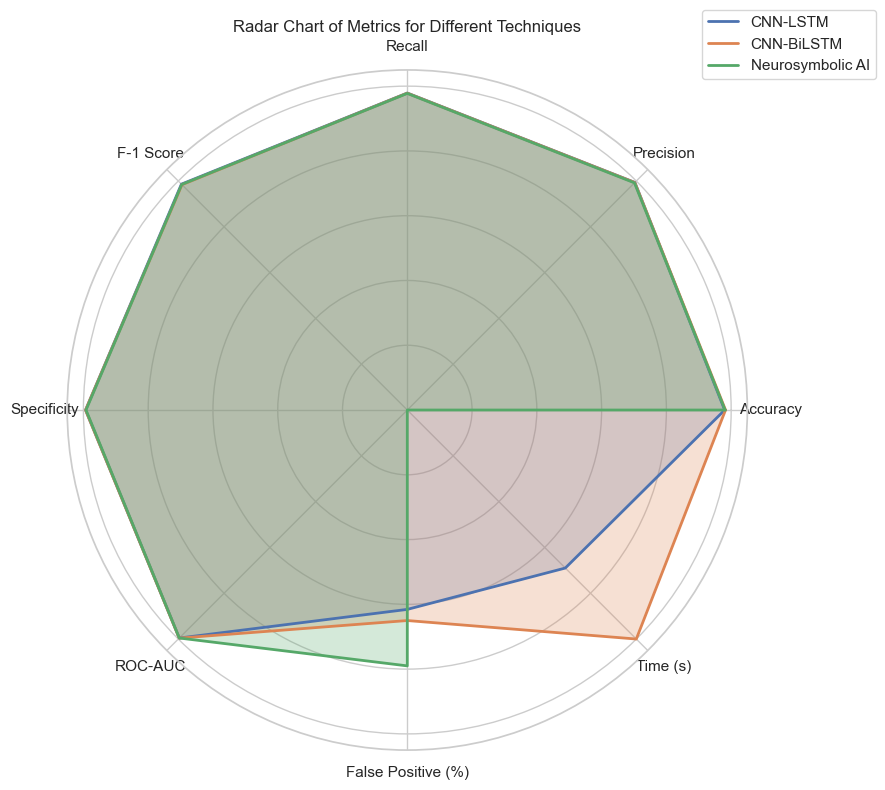

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Data
labels = ['Accuracy', 'Precision', 'Recall', 'F-1 Score', 'Specificity', 'ROC-AUC', 'False Positive (%)', 'Time (s)']
data = {
    'CNN-LSTM': [0.9800, 0.9938, 0.9788, 0.9863, 0.9934, 0.9957, 0.6156, 0.69],
    'CNN-BiLSTM': [0.9826, 0.9934, 0.9784, 0.9839, 0.9935, 0.9960, 0.65, 1.00],
    'Neurosymbolic AI': [0.9814, 0.9920, 0.9776, 0.9848, 0.9921, 0.9956, 0.79, 0.00]
}

# Add the first value to the end to close the radar chart
for technique in data:
    data[technique].append(data[technique][0])

# Compute angle for each axis
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

# Plot
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw=dict(polar=True))

for technique, values in data.items():
    ax.plot(angles, values, label=technique, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

# Labels and title
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title('Radar Chart of Metrics for Different Techniques')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

# Display the plot
plt.tight_layout()
plt.show()
